In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import re
from collections import defaultdict

In [19]:
# Load the Excel file
file_path = '/data_disk/lichx/Predict/Influenza_Forecasting/Output/汇总-画图用.xlsx'
data = pd.read_excel(file_path, sheet_name=0)

## Train
dt1 = data.iloc[1:8, 1:] # diff
dt2 = data.iloc[13:-1:, 1:] # inverse


In [20]:
def extract_models(columns):
    """
    提取模型名称

    参数:
    columns (list): 包含列名的列表。

    返回:
    list: 包含模型名称的排序列表。
    """
    chinese_to_english = {
        '（': '(',
        '）': ')'
    }
    unique_models = []
    models = set()

    for col in columns:
        if col.startswith('Methods'):
            continue
        
        col = ''.join(chinese_to_english.get(char, char) for char in col)
        match = re.match(r'^[^\.]+', col)
        if match:
            model = match.group(0)
            if model not in models:
                unique_models.append(model)
                models.add(model)

    return unique_models

def generate_color_list(methods):
    """
    根据给定列表的长度生成一个颜色列表，用于绘图。

    参数:
    methods (list): 需要生成颜色列表的参考列表。

    返回:
    list: 包含颜色代码的列表。
    """

    num_colors = len(methods)
    
    # 使用matplotlib的colormap来生成颜色列表
    cmap = plt.get_cmap('tab20')  # 选择一个colormap，这里使用'tab20'
    
    # 生成颜色列表
    color_list = [cmap(i) for i in range(num_colors)]
    
    return color_list

In [21]:
# 参数设置    
metrics = data.iloc[0, 1:7].values
methods1 = extract_models(data.columns)
datasets = ['+%_sChina', '+%_nChina', '+%_usa', '+%_cq', 'ili_sChina', 'ili_nChina', 'ili_cq']
n_datasets = len(datasets) # 数据集
n_methods1 = len(methods1) # 方法
n_metrics = len(metrics) # 指标
width1 = 1  # 每个柱子的宽度
width2 = 0.5  
gap = 0.1
colors1 = generate_color_list(methods1)

In [22]:
def Rank(dt, methods):
    results = {}
    n_methods = len(methods)
    
    for i in range(n_metrics):
        data = [dt.iloc[:, i + (j*n_metrics)] for j in range(n_methods)]
        df = pd.DataFrame(data).T
        df.index = pd.Index(datasets)
        df.columns = methods

        if i <= 1:
            top2_indices = df.apply(lambda x: x.argsort()[-2:][::-1], axis=1)
        else:
            top2_indices = df.apply(lambda x: x.argsort()[:2], axis=1)

        top2_methods = top2_indices.apply(lambda x: [methods[i] for i in x], axis=1)
        top2_methods = pd.DataFrame(top2_methods.tolist(), index=top2_methods.index, columns=[1, 2])
        results[f'{metrics[i]}_Top2_Models'] = top2_methods

    return results


def counts_all(r):
    """
    汇总结果
    """
    ranking_counts = defaultdict(lambda: {'1': 0, '2': 0})

    for df_key, df in r.items():
        for rank, col in enumerate(df.columns, start=1):
            for model in df[col]:
                ranking_counts[model][f'{rank}'] += 1

    ranking_df = pd.DataFrame.from_dict(ranking_counts, orient='index')
    ranking_df = ranking_df.sort_index()

    ranking_df['Sum'] = ranking_df[['1', '2']].sum(axis=1)
    ranking_df = ranking_df.sort_values(by='Sum', ascending=False)

    return ranking_df


def counts(r):
    """
    单个指标结果
    """
    ranking_counts_dict = {}

    for key, df in r.items():
        ranking_counts = defaultdict(lambda: {'1': 0, '2': 0})
        
        for rank, col in enumerate(df.columns, start=1):
            for model in df[col]:
                ranking_counts[model][f'{rank}'] += 1
        
        ranking_df = pd.DataFrame.from_dict(ranking_counts, orient='index')
        ranking_df['Sum'] = ranking_df[['1', '2']].sum(axis=1)
        ranking_df = ranking_df.sort_values(by='Sum', ascending=False)
        
        ranking_counts_dict[key] = ranking_df

    return ranking_counts_dict
  

def show(r):
    for key, ranking_df in r.items():
        print(f"Results for {key}:\n")
        print(ranking_df)
        print("\n" + "="*50 + "\n")

def rmNaN(df):
    df_cleaned = df.dropna(axis=1, how='all')
    return df_cleaned

def show_ranks(df):
    print(counts_all(Rank(df, extract_models(df.columns))))


In [23]:
# dt2.columns = dt2.columns.str.replace(r'\(leaky_relu\)', '', regex=True)
# dt2.columns = dt2.columns.str.replace(r'\(new\)', '', regex=True)
selected_models = ['Llama2(relu_new)', 'GPT2（6）', 'SARIMA', 'LSTM_13', 'PatchTST', 'CoVtransformer', 'FEDformer', 'GPT4TS', 'TimeLLM']
dt = dt2[[col for col in dt2.columns if any(model in col for model in selected_models)]]
dt = dt.reset_index(drop=True)
dt = dt.apply(pd.to_numeric, errors='coerce')

# 输出修改后的列名
dt


,GPT2（6）,GPT2（6）.1,GPT2（6）.2,GPT2（6）.3,GPT2（6）.4,GPT2（6）.5,PatchTST,PatchTST.1,PatchTST.2,PatchTST.3,...,TimeLLM.2,TimeLLM.3,TimeLLM.4,TimeLLM.5,GPT4TS,GPT4TS.1,GPT4TS.2,GPT4TS.3,GPT4TS.4,GPT4TS.5
0,0.768867,0.836367,2.034733,8.403833e+00,3.135313e+01,26.664467,0.737567,0.793033,2.549700,1.166507e+01,...,2.2144,1.066370e+01,3.217780e+01,26.3148,0.7507,0.8216,2.5074,1.156060e+01,3.961240e+01,32.9161
1,0.816533,0.838867,2.454233,1.324340e+01,3.682183e+01,32.372467,0.755533,0.781133,2.489333,1.110443e+01,...,2.7589,1.637710e+01,3.913900e+01,34.1938,0.7725,0.8090,2.6589,1.428170e+01,5.374110e+01,39.4889
2,0.731367,0.808267,1.291233,3.070667e+00,1.636013e+01,16.751900,0.736267,0.828300,1.191767,2.609067e+00,...,1.3468,3.451800e+00,1.452550e+01,13.8858,0.7543,0.8329,1.2551,2.936600e+00,1.525400e+01,15.2002
3,0.413200,0.414267,0.094567,1.576667e-02,2.445284e+08,98.455300,0.374867,0.414233,0.092500,1.446667e-02,...,0.0980,1.737000e-02,2.525933e+08,97.4561,0.3874,0.3911,0.0990,1.693000e-02,2.317127e+08,99.8233
4,0.828667,0.836767,5764.666667,9.447657e+07,6.365767e+00,6.396467,0.761533,0.804933,6109.333333,9.597311e+07,...,6831.8425,1.374586e+08,7.495200e+00,7.3679,0.7567,0.7815,8038.1691,1.542873e+08,9.265000e+00,9.2976
5,0.845300,0.876400,3475.666667,2.677256e+07,7.339533e+00,7.411800,0.796900,0.835000,3600.333333,2.578840e+07,...,4051.9000,3.711469e+07,8.326100e+00,8.2266,0.8109,0.8395,4469.4702,3.993565e+07,9.710800e+00,9.7823
6,0.685833,0.717367,72.780533,9.069333e+03,2.502957e+01,22.222700,0.463467,0.477367,73.684800,8.981333e+03,...,45.4439,4.870785e+03,2.533190e+01,23.9523,0.3518,0.3355,48.0230,5.042869e+03,2.758890e+01,26.4206


In [ ]:
dt['model'] = dt['model'].replace({'CovT':'CoVTransformer', 'FEDF':'FEDformer', 'TimeLLM':'Time-LLM'})

In [24]:
dt["GPT4TS.2"] = [2.19, 2.61, 1.162, 0.092, 6752.2, 3919.44, 44.703]

In [33]:
sss=1
f'{sss}'

'1'

In [39]:
first_col = [col for col in dt.columns if not ('.' in col)]
end = '.2'
name = 'MAE'
cols = [col for col in dt.columns if col.endswith(end)]

# metric = dt2[first_col]
metric = dt[cols]
metric = metric.rename(columns={col: col.replace(end, '') for col in metric.columns})
metric.columns = ['GPT2', 'PatchTST', 'Llama2', 'LSTM', 'CoVTransformer', 'FEDformer', 'SARIMA', 'Time-LLM', 'GPT4TS']
# print(metric)
metric.iloc[[2, 3]] = metric.iloc[[3, 2]].values # 交换数据集位置
# print(metric)
order = ['SARIMA', 'LSTM', 'PatchTST', 'CoVTransformer', 'FEDformer', 'Time-LLM', 'GPT4TS', 'GPT2', 'Llama2',]
metric = metric[order]
metric

,SARIMA,LSTM,PatchTST,CoVTransformer,FEDformer,Time-LLM,GPT4TS,GPT2,Llama2
0,4.045453,2.082333,2.549700,2.084850,2.2063,2.2144,2.190,2.034733,2.193667
1,4.338746,2.665933,2.489333,2.604400,2.7273,2.7589,2.610,2.454233,2.240633
2,0.103741,0.096500,0.092500,0.095467,0.0992,0.0980,0.092,0.094567,0.085133
3,2.870797,1.288600,1.191767,1.185800,1.2999,1.3468,1.162,1.291233,1.185300
4,17887.360757,6595.407000,6109.333333,6587.004633,6688.7378,6831.8425,6752.200,5764.666667,6576.990700
5,7354.413994,3870.010700,3600.333333,3872.174700,3898.1599,4051.9000,3919.440,3475.666667,3523.969567
6,57.411041,44.367767,73.684800,44.487333,44.2187,45.4439,44.703,72.780533,54.419500


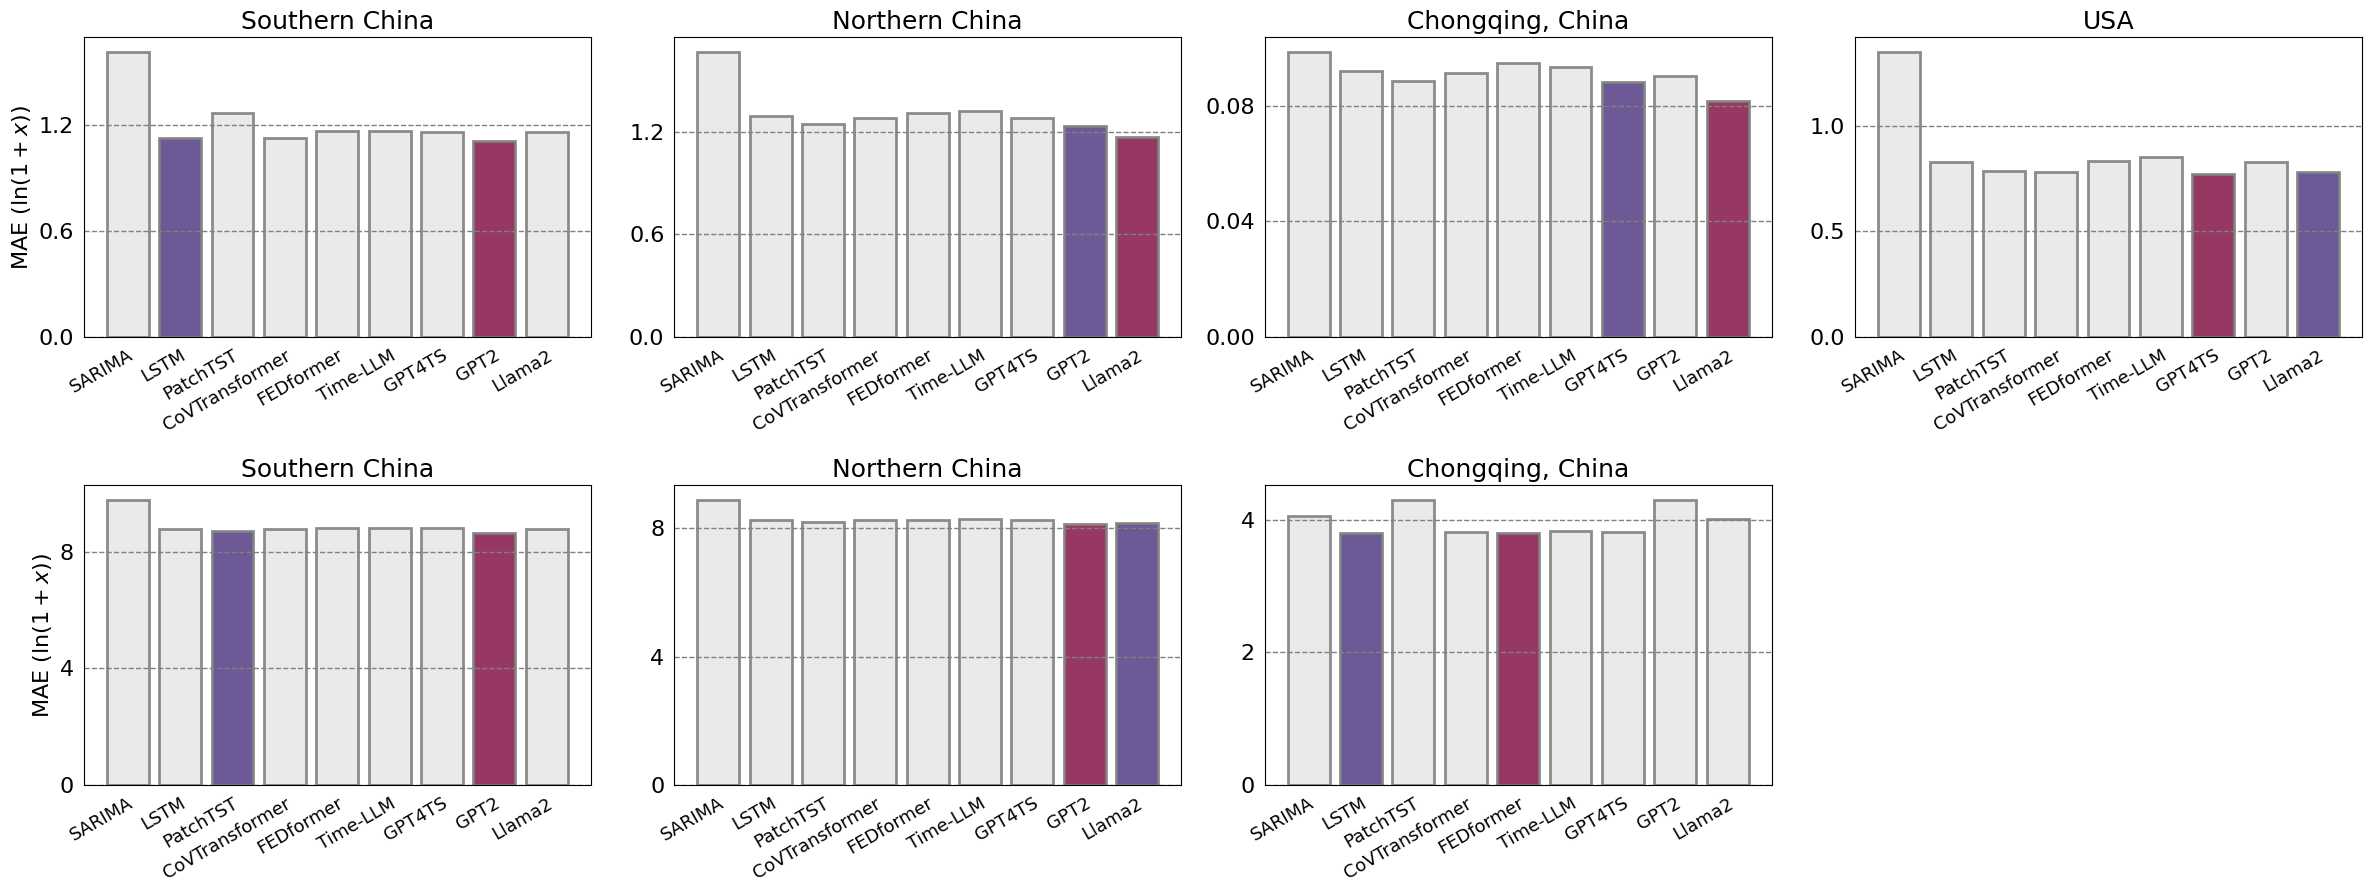

In [40]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from matplotlib.ticker import MaxNLocator

matplotlib.rcParams['font.size'] = 16  # 设置全局字体大小

# 数据集名称
dataset_names = ['Southern China', 'Northern China', 'Chongqing, China', 'USA',
                 'Southern China', 'Northern China', 'Chongqing, China']

if metric.values.max() > 10:
    metric_scaled = np.log1p(metric)
    MAE = r'MAE ($\ln(1+x)$)'
else:
    metric_scaled = metric
    MAE = name

# 创建一张图：2 行 4 列
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(24, 10))

# 第一行：前 4 个数据集
for i in range(4):
    ax = axes[0, i]
    mae_row_scaled = metric_scaled.iloc[i].values
    title = f"{dataset_names[i]}"

    max_idx = mae_row_scaled.argmax()
    min_idx = mae_row_scaled.argmin()
    second_max_idx = (mae_row_scaled.argsort())[-2]
    second_min_idx = (mae_row_scaled.argsort())[1]

    colors = ['#8B2252' if idx == min_idx else '#5D478B' if idx == second_min_idx else '#E8E8E8'
              for idx in range(len(mae_row_scaled))]

    ax.bar(metric.columns, mae_row_scaled, color=colors, alpha=0.9, edgecolor='grey', linewidth=2)
    ax.set_title(title, fontsize=18)

    if i == 0:
        ax.set_ylabel(MAE, fontsize=16)

    ax.set_ylim(bottom=0)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=3))
    ax.set_xticks(range(len(metric.columns)))
    ax.set_xticklabels(metric.columns, rotation=30, ha='right', rotation_mode='anchor', fontsize=13)
    ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=True)
    ax.tick_params(axis='y', which='both', left=False, right=False, labelsize=16)
    ax.grid(True, linestyle='--', color='grey', axis='y', which='both', linewidth=1)

# 第二行：后 3 个数据集
for i in range(3):
    ax = axes[1, i]
    mae_row_scaled = metric_scaled.iloc[i + 4].values
    title = f"{dataset_names[i + 4]}"

    max_idx = mae_row_scaled.argmax()
    min_idx = mae_row_scaled.argmin()
    second_max_idx = (mae_row_scaled.argsort())[-2]
    second_min_idx = (mae_row_scaled.argsort())[1]

    colors = ['#8B2252' if idx == min_idx else '#5D478B' if idx == second_min_idx else '#E8E8E8'
              for idx in range(len(mae_row_scaled))]

    ax.bar(metric.columns, mae_row_scaled, color=colors, alpha=0.9, edgecolor='grey', linewidth=2)
    ax.set_title(title, fontsize=18)

    if i == 0:
        ax.set_ylabel(MAE, fontsize=16)

    ax.set_ylim(bottom=0)
    ax.yaxis.set_major_locator(MaxNLocator(nbins=3))
    ax.set_xticks(range(len(metric.columns)))
    ax.set_xticklabels(metric.columns, rotation=30, ha='right', rotation_mode='anchor', fontsize=13)
    ax.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=True)
    ax.tick_params(axis='y', which='both', left=False, right=False, labelsize=16)
    ax.grid(True, linestyle='--', color='grey', axis='y', which='both', linewidth=1)

# 第二行最后一个子图关闭
axes[1, -1].axis("off")

fig.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

# 保存
fig.savefig(f'/data_disk/lichx/Predict/Influenza_Forecasting/Output/r2/{name}_9models.pdf', dpi=300, bbox_inches='tight')


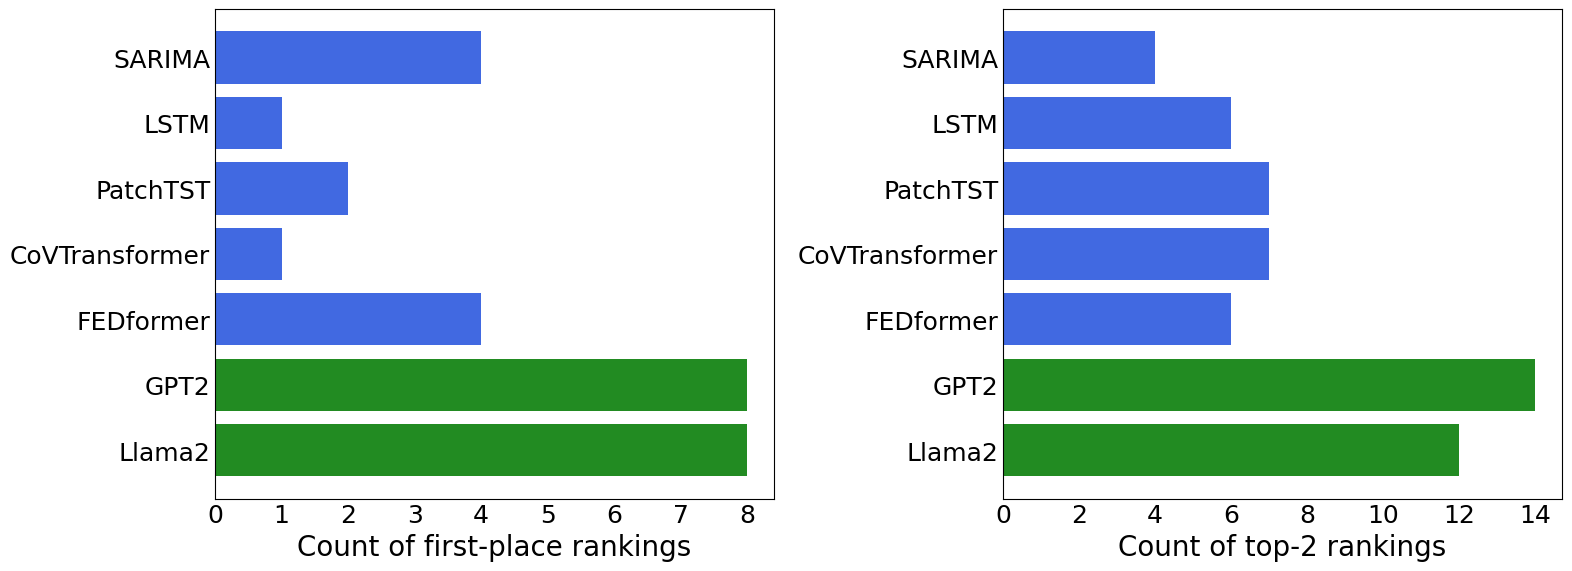

In [16]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.patches import Patch

data_all = {
    "Model": [
        "SARIMA", "LSTM", "PatchTST", "CoVTransformer", "FEDformer", "GPT2", "Llama2"
    ],
    "Best": [4, 1, 2, 1, 4, 8, 8],
    "Sum": [4, 6, 7, 7, 6, 14, 12]  # 17->16
}

df = pd.DataFrame(data_all)
df = df.iloc[::-1]  # 反转顺序方便展示

color1 = 'forestgreen'
color2 = 'royalblue'
colors = [color1 if i < 2 else color2 for i in range(len(df))]

# 创建两个子图
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左边：first-place
bars1 = axes[0].barh(df["Model"], df["Best"], color=colors, alpha=1)
axes[0].set_xlabel("Count of first-place rankings", fontsize=20)
axes[0].xaxis.set_major_locator(plt.MaxNLocator(integer=True))
axes[0].tick_params(axis='x', labelsize=18, length=0)
axes[0].tick_params(axis='y', labelsize=18, length=0)
axes[0].grid(False)

# 右边：top-2
bars2 = axes[1].barh(df["Model"], df["Sum"], color=colors, alpha=1)
axes[1].set_xlabel("Count of top-2 rankings", fontsize=20)
axes[1].xaxis.set_major_locator(plt.MaxNLocator(integer=True))
axes[1].tick_params(axis='x', labelsize=18, length=0)
axes[1].tick_params(axis='y', labelsize=18, length=0)
axes[1].grid(False)

# 图例放在右下角（整体）
legend_elements = [
    Patch(facecolor=color2, edgecolor='black', label='Classical Models'),
    Patch(facecolor=color1, edgecolor='black', label='Large Language Models')
]
# axes[1].legend(handles=legend_elements, loc='lower right', fontsize=16, bbox_to_anchor=(1.0, 0.025))

plt.tight_layout()

plt.savefig('/data_disk/lichx/Predict/Influenza_Forecasting/Output/11_13_png/Counts_first_and_top2.pdf',
            dpi=300, bbox_inches='tight')

plt.show()
plt.close()


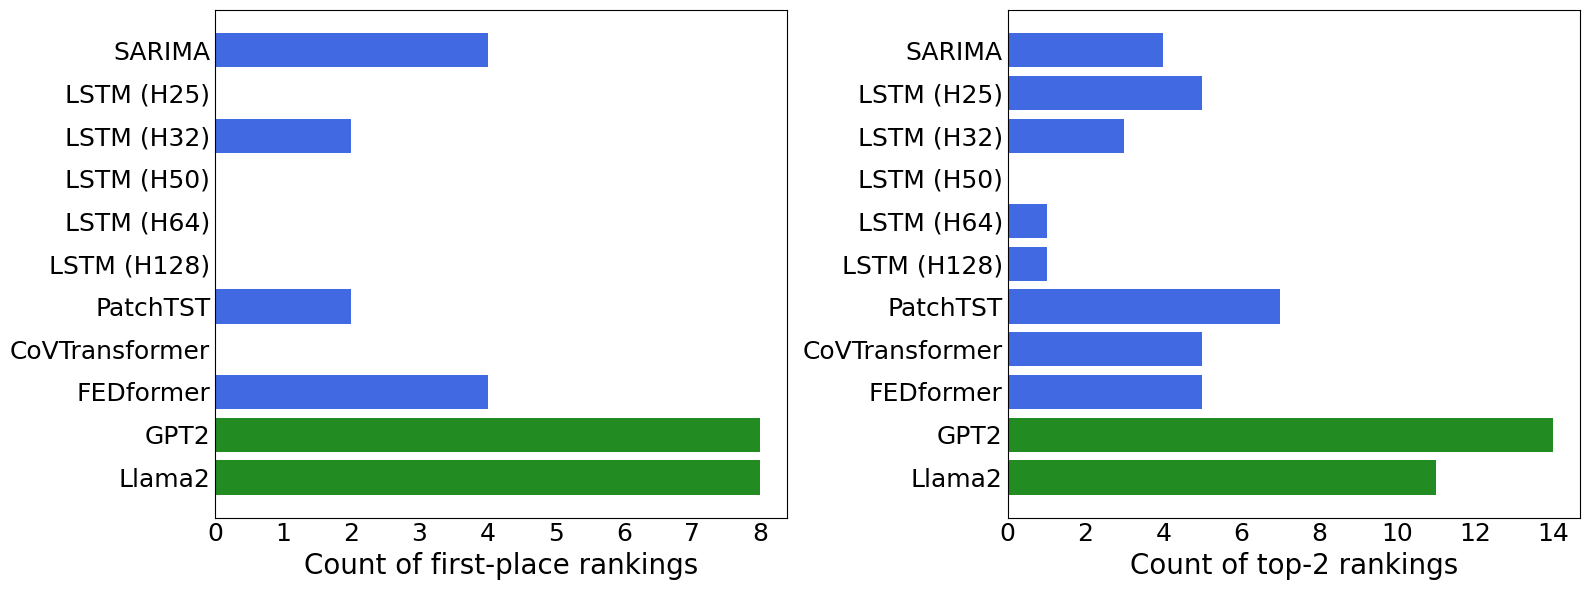

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.patches import Patch

data_all = {
    "Model": [
        "SARIMA", "LSTM (H25)", "LSTM (H32)", "LSTM (H50)", "LSTM (H64)", "LSTM (H128)",
        "PatchTST", "CoVTransformer", "FEDformer", "GPT2", "Llama2"
    ],
    "Best": [4, 0, 2, 0, 0, 0, 2, 0, 4, 8, 8],
    "Sum":  [4, 5, 3, 0, 1, 1, 7, 5, 5, 14, 11]
}


df = pd.DataFrame(data_all)
df = df.iloc[::-1]  # 反转顺序方便展示

color1 = 'forestgreen'
color2 = 'royalblue'
colors = [color1 if i < 2 else color2 for i in range(len(df))]

# 创建两个子图
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 左边：first-place
bars1 = axes[0].barh(df["Model"], df["Best"], color=colors, alpha=1)
axes[0].set_xlabel("Count of first-place rankings", fontsize=20)
axes[0].xaxis.set_major_locator(plt.MaxNLocator(integer=True))
axes[0].tick_params(axis='x', labelsize=18, length=0)
axes[0].tick_params(axis='y', labelsize=18, length=0)
axes[0].grid(False)

# 右边：top-2
bars2 = axes[1].barh(df["Model"], df["Sum"], color=colors, alpha=1)
axes[1].set_xlabel("Count of top-2 rankings", fontsize=20)
axes[1].xaxis.set_major_locator(plt.MaxNLocator(integer=True))
axes[1].tick_params(axis='x', labelsize=18, length=0)
axes[1].tick_params(axis='y', labelsize=18, length=0)
axes[1].grid(False)

# 图例放在右下角（整体）
legend_elements = [
    Patch(facecolor=color2, edgecolor='black', label='Classical Models'),
    Patch(facecolor=color1, edgecolor='black', label='Large Language Models')
]
# axes[1].legend(handles=legend_elements, loc='lower right', fontsize=16, bbox_to_anchor=(1.0, 0.025))

plt.tight_layout()

plt.savefig('/data_disk/lichx/Predict/Influenza_Forecasting/Output/11_13_png/Counts_first_and_top2_LSTM_variants.pdf',
            dpi=300, bbox_inches='tight')

plt.show()
plt.close()


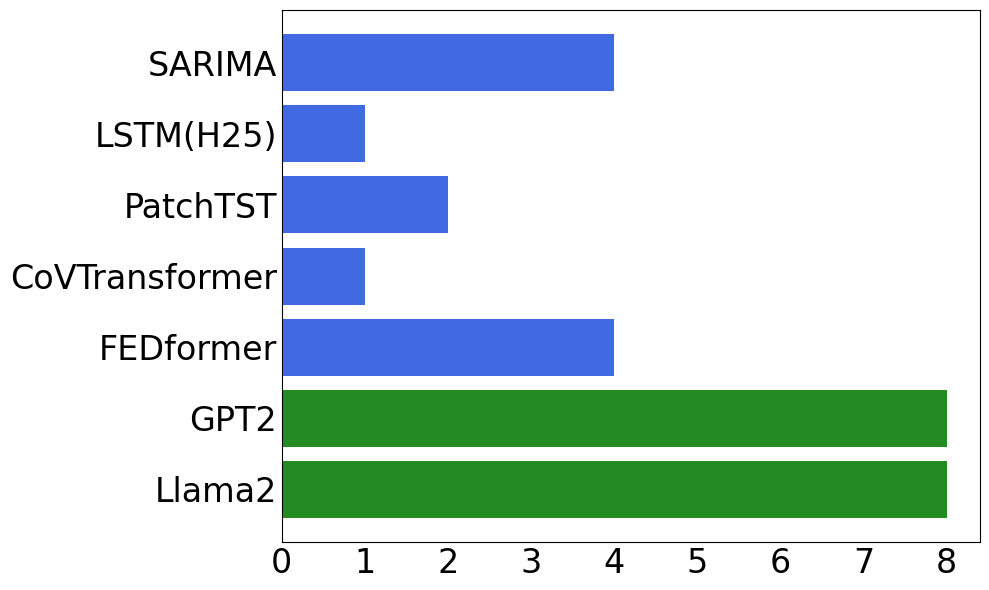

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from matplotlib.patches import Patch

data_all = {
    "Model": [
        "SARIMA", "LSTM(H25)", "PatchTST", "CoVTransformer", "FEDformer", "GPT2", "Llama2"
    ],
    "Best": [4, 1, 2, 1, 4, 8, 8],
    "Sum": [4, 8, 7, 7, 5, 14, 11]  # 17->16
}

df = pd.DataFrame(data_all)
df = df.iloc[::-1]

fig, ax = plt.subplots(figsize=(10, 6))

color1 = 'forestgreen'
color2 = 'royalblue'
colors = [color1 if i < 2 else color2 for i in range(len(df))]

bars = ax.barh(df["Model"], df["Best"], color=colors, alpha=1)
# bars = ax.barh(df["Model"], df["Sum"], color=colors, alpha=1)

# ax.set_xlabel("Counts of Best", fontsize=20)
# ax.set_xlabel("Counts of Best and Second Best", fontsize=20)

ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))

ax.tick_params(axis='x', which='both', labelsize=24, length=0)
ax.tick_params(axis='y', which='both', labelsize=24, length=0)
ax.grid(False)

legend_elements = [
    Patch(facecolor=color2, edgecolor='black', label='Classical Models'),
    Patch(facecolor=color1, edgecolor='black', label='Large Language Models')
]
# ax.legend(handles=legend_elements, loc='lower right', fontsize=14, bbox_to_anchor=(1, 0.025))

plt.tight_layout()

plt.savefig(f'/data_disk/lichx/Predict/Influenza_Forecasting/Output/11_13_png/Counts_of_best_error_metrics_h25_7models.pdf', dpi=300, bbox_inches='tight')
# plt.savefig(f'/data_disk/lichx/Predict/Influenza_Forecasting/Output/11_13_png/Counts_of_best_and_second_best_error_metrics.pdf', dpi=300, bbox_inches='tight')

# 显示图表
plt.show()
plt.close()

In [21]:
print(df)
columns = df.columns[1:]
for i, column in enumerate(columns):

        # 剔除为0的模型
        data_filtered = df[df[column] > 0]
        print(data_filtered)


      Model  Southern  Northern  USA  ILI of Southern  ILI of Northern
6    Llama3         0         0    0                0                0
5    Llama2         0         2    3                0                2
4      GPT4         0         0    0                1                1
3   GPT2(6)         2         2    0                3                0
2  PatchTST         0         0    1                0                1
1      LSTM         2         0    0                0                1
0    SARIMA         2         2    2                2                1
     Model  Southern  Northern  USA  ILI of Southern  ILI of Northern
3  GPT2(6)         2         2    0                3                0
1     LSTM         2         0    0                0                1
0   SARIMA         2         2    2                2                1
     Model  Southern  Northern  USA  ILI of Southern  ILI of Northern
5   Llama2         0         2    3                0                2
3  GPT2(6)  

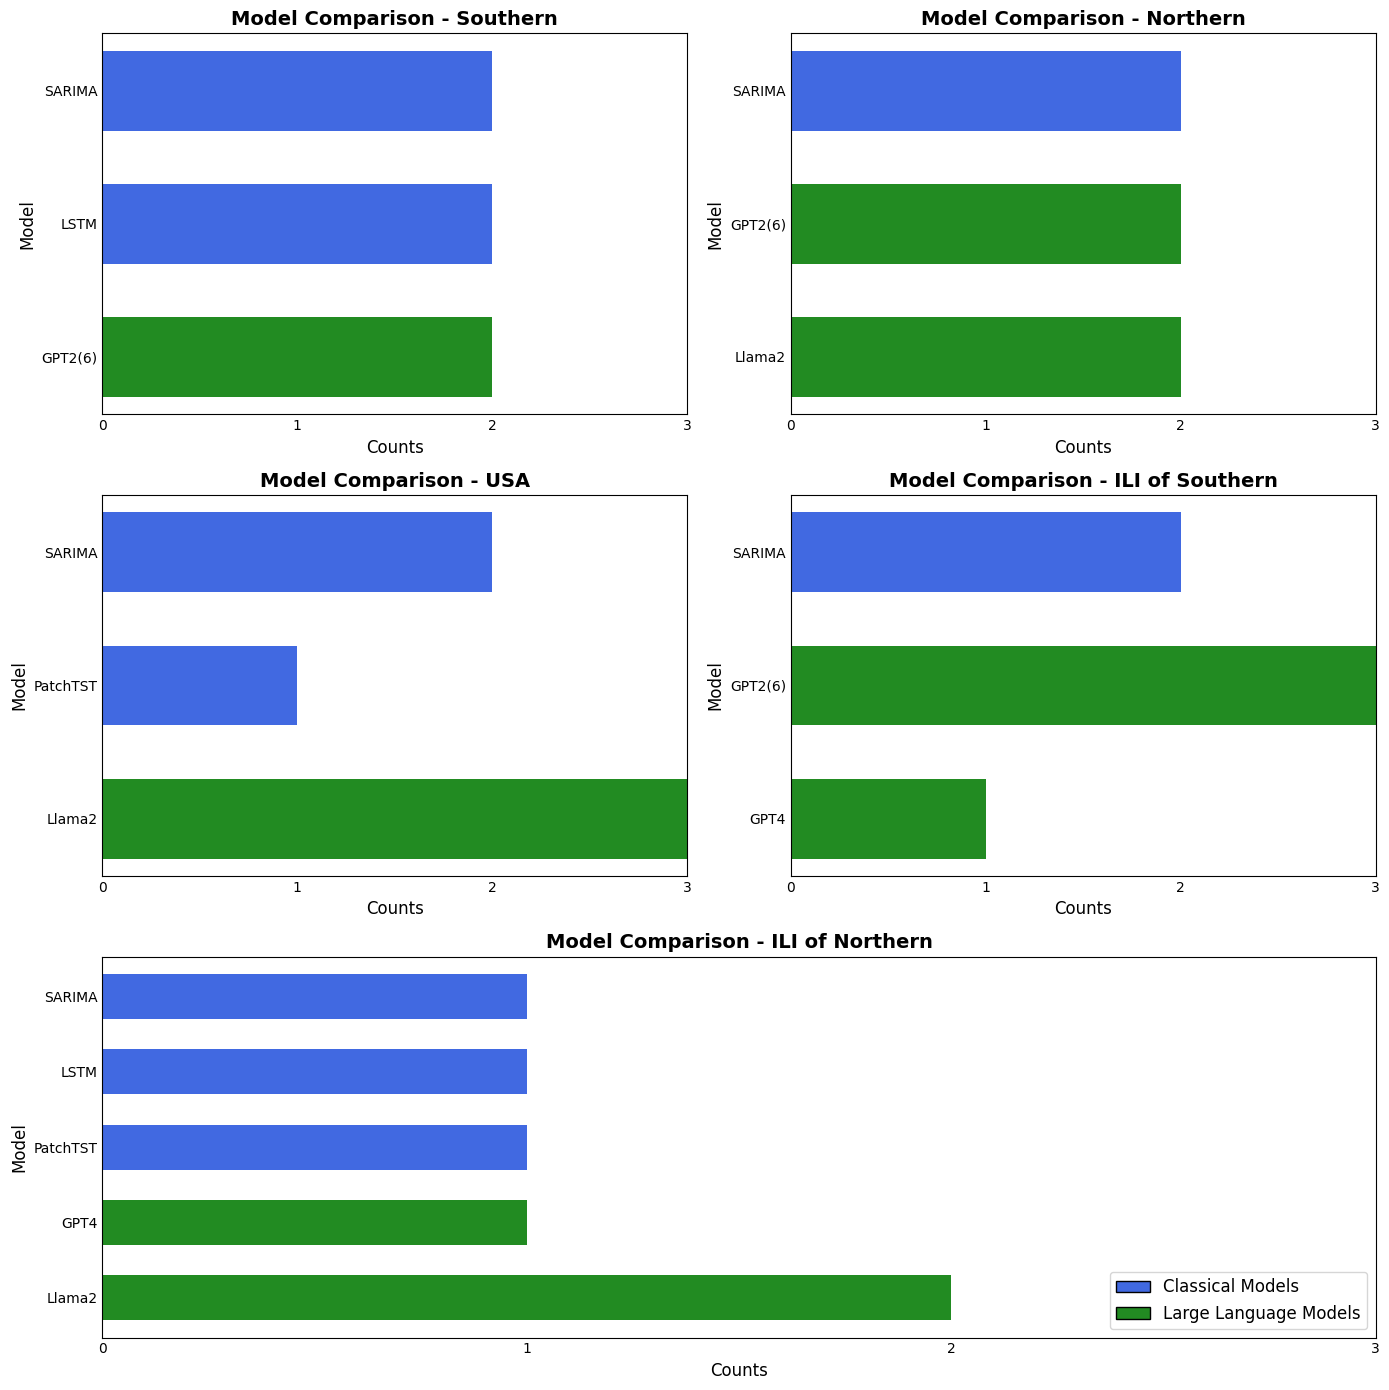

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# 数据
data_cn = {
    "Model": [
        "SARIMA", "LSTM", "PatchTST", "GPT2(6)",
        "GPT4", "Llama2", "Llama3"
    ],
    "Southern": [2, 2, 0, 2, 0, 0, 0],
    "Northern": [2, 0, 0, 2, 0, 2, 0],
    "USA": [2, 0, 1, 0, 0, 3, 0],
    "ILI of Southern": [2, 0, 0, 3, 1, 0, 0],
    "ILI of Northern": [1, 1, 1, 0, 1, 2, 0]
}

# 转换为 DataFrame
df = pd.DataFrame(data_cn)

# 反转行顺序
df = df.iloc[::-1]

# 绘图函数
# 将图表放入3行2列的画布中
# 修改第五张图占据第三行全部
def plot_multiple_charts_full_width_fifth(data):
    fig, axes = plt.subplots(3, 2, figsize=(14, 14))
    fig.subplots_adjust(hspace=0.4, wspace=0.3)  # 调整子图之间的间距

    columns = data.columns[1:]  # 数据集列名
    color1 = 'forestgreen'
    color2 = 'royalblue'
    legend_elements = [
        Patch(facecolor=color2, edgecolor='black', label='Classical Models'),
        Patch(facecolor=color1, edgecolor='black', label='Large Language Models')
    ]

    for i, column in enumerate(columns):
        if i < 4:
            row, col = divmod(i, 2)  # 前四张图计算子图的行列索引
            ax = axes[row, col]
        else:
            # 第五张图占据第三行两列
            ax = fig.add_subplot(3, 1, 3)  # 合并第三行两列为一个完整子图
            axes[2, 0].axis('off')  # 隐藏原有子图
            axes[2, 1].axis('off')

        # 剔除为0的模型
        data_filtered = data[data[column] > 0]
        colors = [color1 if "GPT" in model or "Llama" in model else color2 for model in data_filtered["Model"]]

        # 绘制条形图
        ax.barh(data_filtered["Model"], data_filtered[column], color=colors, alpha=1, height=0.6)
        ax.set_xlim(0, 3)  # 设置x轴范围
        
        # 设置标题和标签
        ax.set_title(f"Model Comparison - {column}", fontsize=14, fontweight="bold")
        ax.set_xlabel("Counts", fontsize=12)
        ax.set_ylabel("Model", fontsize=12)
        
        # 调整坐标和网格
        ax.xaxis.set_major_locator(plt.MaxNLocator(integer=True))
        ax.tick_params(axis='x', which='both', length=0)
        ax.tick_params(axis='y', which='both', length=0)
        ax.grid(False)

        if i == 4:  # 第五张图添加图例
            ax.legend(handles=legend_elements, loc='lower right', fontsize=12)

    # 显示所有图
    plt.tight_layout()
    plt.show()

# 绘制合并的子图
plot_multiple_charts_full_width_fifth(df)




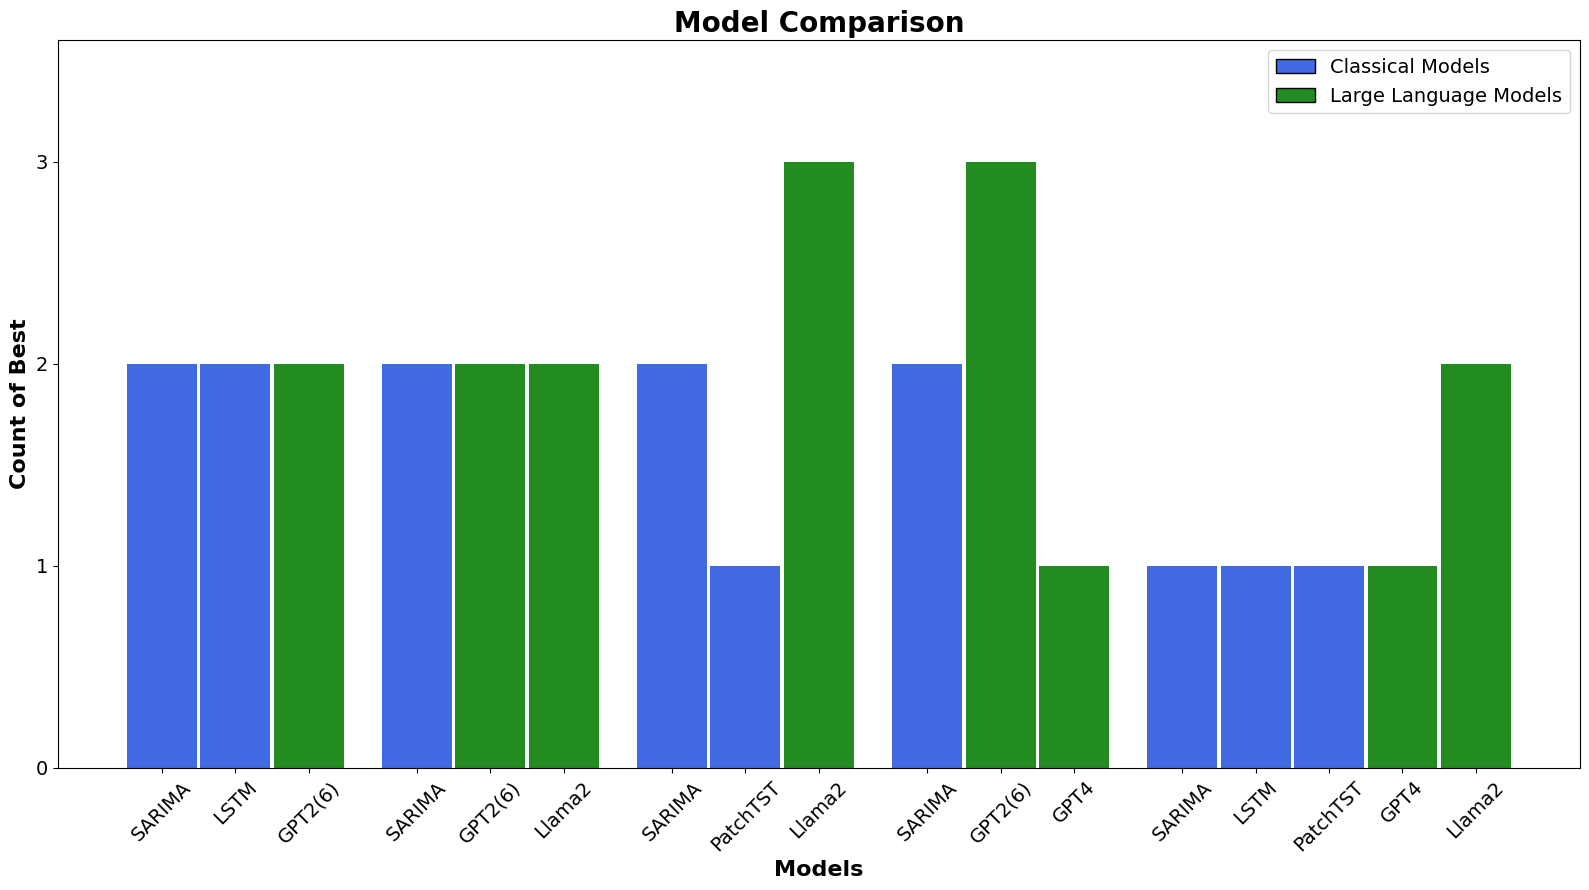

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# 数据
data_cn = {
    "Model": [
        "SARIMA", "LSTM", "PatchTST", "GPT2(6)",
        "GPT4", "Llama2", "Llama3"
    ],
    "Southern": [2, 2, 0, 2, 0, 0, 0],
    "Northern": [2, 0, 0, 2, 0, 2, 0],
    "USA": [2, 0, 1, 0, 0, 3, 0],
    "ILI of Southern": [2, 0, 0, 3, 1, 0, 0],
    "ILI of Northern": [1, 1, 1, 0, 1, 2, 0]
}

# 转换为 DataFrame
df = pd.DataFrame(data_cn)

# 修改为去掉网格，并在y轴仅保留模型名称
# 修改代码以确保同一数据集内的模型柱子之间有间隔
def plot_filtered_grouped_bar_with_spacing(data, title):
    fig, ax = plt.subplots(figsize=(16, 9))
    
    # 数据集列名和模型
    columns = data.columns[1:]
    bar_width = 0.1  # 每个柱子的宽度
    dataset_gap = 0.05  # 数据集间的间隔
    model_gap = 0.005  # 模型柱子之间的间隔

    x_positions = []
    flat_x_labels = []
    all_heights = []
    dataset_positions = []

    # 设置颜色
    color1 = 'forestgreen'
    color2 = 'royalblue'

    # 计算柱子的位置并绘制图表
    for i, column in enumerate(columns):
        # 筛选当前数据集中大于0的模型
        data_filtered = data[data[column] > 0]
        num_models = len(data_filtered)

        # 计算x位置，增加模型间的间隔
        start_pos = i * (3 * (bar_width + model_gap) + dataset_gap)
        positions = [start_pos + j * (bar_width + model_gap) for j in range(num_models)]
        x_positions.extend(positions)

        flat_x_labels.extend([f"{model}" for model in data_filtered["Model"]])
        all_heights.extend(data_filtered[column])

        colors = [
            color1 if "GPT" in model or "Llama" in model else color2 
            for model in data_filtered["Model"]
        ]
        ax.bar(positions, data_filtered[column], width=bar_width, color=colors, alpha=1)
        
    # 设置x轴刻度和标签
    ax.set_xticks(x_positions)
    ax.set_xticklabels(flat_x_labels, fontsize=14, rotation=45, ha='center')

    # 设置标题和标签
    ax.set_title(title, fontsize=20, fontweight="bold")
    ax.set_xlabel("Models", fontsize=16, fontweight="bold")
    ax.set_ylabel("Count of Best", fontsize=16, fontweight="bold")
    
    # 添加图例
    legend_elements = [
        Patch(facecolor=color2, edgecolor='black', label='Classical Models'),
        Patch(facecolor=color1, edgecolor='black', label='Large Language Models')
    ]
    ax.legend(handles=legend_elements, loc='upper right', fontsize=14)
    
    # 动态调整y轴范围
    max_value = max(all_heights) if all_heights else 0
    ax.set_ylim(0, max_value * 1.2)
    ax.yaxis.set_major_locator(plt.MaxNLocator(integer=True))
    ax.tick_params(axis='y', labelsize=14)
    ax.grid(False)

    plt.tight_layout()
    plt.savefig(f'/data_disk/lichx/NeurIPS2023-One-Fits-All/Long-term_Forecasting/Output/11_13_png/Counts_of_CN.pdf', dpi=300, bbox_inches='tight')
    plt.show()

# 绘制增加模型柱子间隔的柱状图
plot_filtered_grouped_bar_with_spacing(df, "Model Comparison")



# 11/29

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import FuncFormatter

In [37]:
# 自定义的格式化函数
def custom_formatter(x, pos):
    if x < 10:
        return f"{x:.2f}"  # 小于10保留两位小数
    elif x < 100:
        return f"{x:.1f}"  # 10到100之间保留一位小数
    else:
        return f"{int(x)}"  # 大于等于100保留整数

In [50]:
data = pd.read_excel("/data_disk/lichx/NeurIPS2023-One-Fits-All/Influenza_Forecasting/Output/summary/summary_llama_layer_values.xlsx", sheet_name=1)
# data = pd.read_excel("/data_disk/lichx/NeurIPS2023-One-Fits-All/Influenza_Forecasting/Output/summary/summary_epochs_with_gpt2_layer_values.xlsx", sheet_name=1)

In [51]:
dt0 = data[data['if_inverse']==0]
dt1 = data[data['if_inverse']==1]
dt0.shape, dt1.shape

((32, 8), (32, 8))

In [53]:
metric_name_mapping = {
    "SpearmanR": r"Spearman's $\it{\rho}$",
    "PearsonR": r"Pearson's $\it{r}$"
}

dt = dt1.copy()
dt = dt.reset_index(drop=True)
dt.columns = ['gpt_layer', 'if_inverse', 'SpearmanR', 'PearsonR', 'MAE', 'MSE', 'MAPE', 'SMAPE']
dt.columns


Index(['gpt_layer', 'if_inverse', 'SpearmanR', 'PearsonR', 'MAE', 'MSE',
       'MAPE', 'SMAPE'],
      dtype='object')

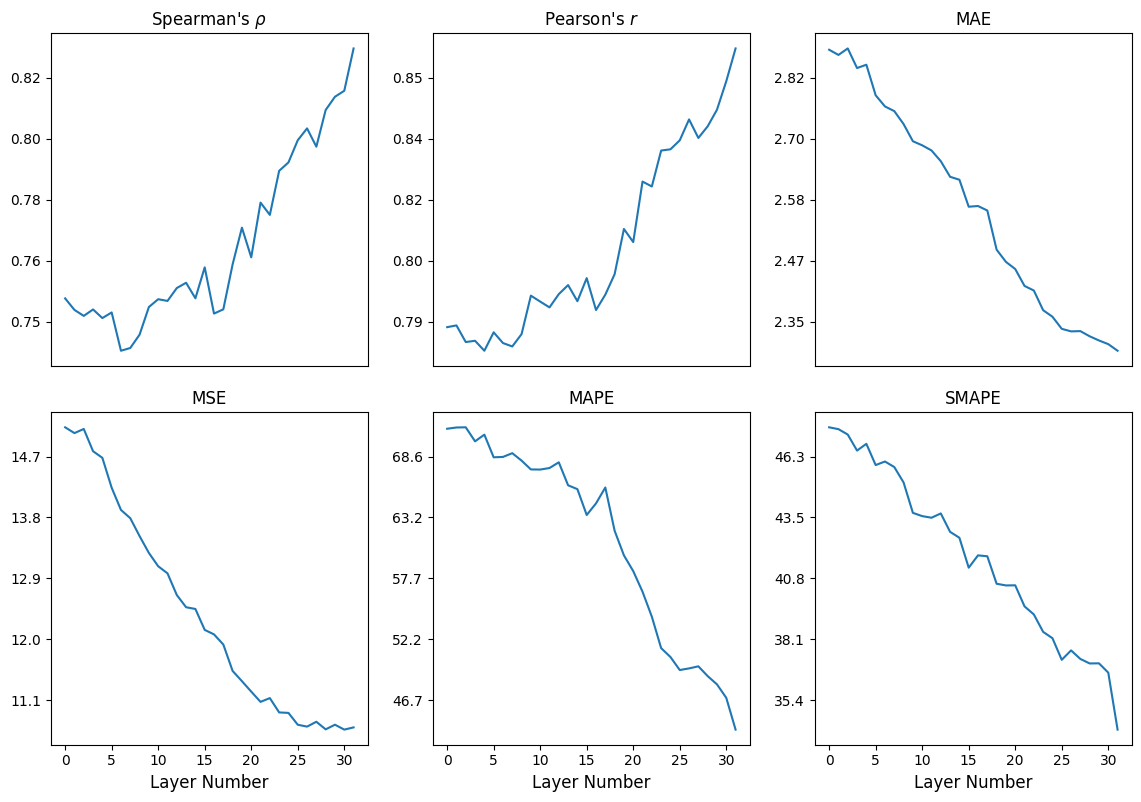

In [55]:
fig, axes = plt.subplots(2, 3, figsize=(11.7, 8.3))  # A4尺寸 (宽, 高)，单位是英寸
axes = axes.flatten()  # 展平数组以便于循环

for i in range(dt.shape[1] - 2):
    metric = dt.columns[i + 2]  # 获取真实列名
    metric_label = metric_name_mapping.get(metric, metric) 

    axes[i].plot(dt.iloc[:, i + 2])
    # axes[i].set_title(f"{dt.columns[i + 2]}", fontsize=12)  # 设置标题字体大小
    axes[i].set_title(metric_label, fontsize=12)  # 设置标题字体大小
    axes[i].tick_params(axis='both', labelsize=10)  # 设置刻度字体大小

    # 获取当前y轴的最小和最大值
    y_min, y_max = axes[i].get_ylim()

    # 扩展y轴范围，避免最小值和最大值作为刻度
    y_range = y_max - y_min
    new_y_min = y_min - 0.05 * y_range  # 在下方扩展5%
    new_y_max = y_max + 0.05 * y_range  # 在上方扩展5%

    # 使用np.linspace生成均匀分布的刻度，避免包含y_min和y_max
    axes[i].set_yticks(np.linspace(new_y_min, new_y_max, 7)[1:-1])  # 取掉第一和最后一个刻度
    axes[i].yaxis.set_major_formatter(FuncFormatter(custom_formatter))
    
    # 去掉第一行子图的x轴标签和刻度
    if i < 3:
        axes[i].set_xticklabels([])  # 去掉x轴刻度标签
        axes[i].set_xticks([])       # 去掉x轴刻度

axes[3].set_xlabel("Layer Number", fontsize=12)  # 添加x轴标签
axes[4].set_xlabel("Layer Number", fontsize=12)  # 添加x轴标签
axes[5].set_xlabel("Layer Number", fontsize=12)  # 添加x轴标签

plt.tight_layout()  # 自动调整布局
plt.savefig("/data_disk/lichx/NeurIPS2023-One-Fits-All/Influenza_Forecasting/Output/11_13_png/metrics_with_different_llama2_layers.pdf", dpi=300, bbox_inches='tight')
# plt.savefig("/data_disk/lichx/NeurIPS2023-One-Fits-All/Influenza_Forecasting/Output/11_13_png/metrics_with_different_gpt_layers.pdf", dpi=300, bbox_inches='tight')
plt.show()

# 12/2

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MaxNLocator

In [2]:
data = pd.read_excel("/data_disk/lichx/Predict/Influenza_Forecasting/Output/summary/summary_pred_len.xlsx", sheet_name=2)

dt0 = data[data['if_inverse']==0].reset_index(drop=True)
dt1 = data[data['if_inverse']==1].reset_index(drop=True)
data.shape, dt0.shape, dt1.shape

((36, 9), (0, 9), (36, 9))

In [3]:
dt = dt1.copy()
dt = dt.fillna(0)

metrics = ['model', 'pred_len', 'if_inverse', 'SpearmanR', 'PearsonR', 'MAE', 'MSE', 'MAPE', 'SMAPE']
dt.columns = metrics
dt['model'] = dt['model'].replace({'CovT':'CoVTransformer', 'FEDF':'FEDformer', 'TimeLLM':'Time-LLM'})
dt

,model,pred_len,if_inverse,SpearmanR,PearsonR,MAE,MSE,MAPE,SMAPE
0,Llama2,1,1,0.000000,0.000000,2.160800,9.796200,48.882367,41.063733
1,Llama2,4,1,0.595833,0.623067,2.341000,10.786367,56.406933,42.655300
2,Llama2,8,1,0.761300,0.771067,2.292867,10.701300,47.551267,37.008667
3,Llama2,13,1,0.816400,0.850700,2.230867,10.215333,43.450867,32.689033
4,SARIMA,1,1,0.000000,0.000000,0.213468,0.045569,11.383878,10.770810
5,SARIMA,4,1,-0.800000,-0.829668,1.774662,3.873708,78.914317,114.472564
6,SARIMA,8,1,0.595238,0.847809,6.736079,48.707112,256.177688,183.103265
7,SARIMA,13,1,0.901099,0.979280,4.338746,33.200655,64.627619,41.876583
8,LSTM,1,1,0.000000,0.000000,2.375833,11.918633,54.951567,39.418633
9,LSTM,4,1,0.608333,0.606984,2.693800,14.485233,64.219967,41.499600


In [4]:
model_colors = {
    "Llama2": "#d7191c",
    "GPT2": "#7b3294",
    "SARIMA": "#fdae61",
    "LSTM": "#abd9e9",
    "PatchTST": "#a6d96a",
    "CoVTransformer": "#636363",       
    "FEDformer": "#1f78b4",
    "Time-LLM": "#8c564b",
    "GPT4TS": "#17becf"
}

# model_order = ["Llama2", "GPT2", "SARIMA", "LSTM", "PatchTST"]
model_order = ["SARIMA", "LSTM", "PatchTST", "CoVTransformer", "FEDformer", "Time-LLM", "GPT4TS", "GPT2", "Llama2"]
# metrics_visual = ["SpearmanR", "PearsonR", "MAE", "MSE", "MAPE", "SMAPE"]
metrics_visual = ["MAE", "MSE", "MAPE", "SMAPE", "SpearmanR", "PearsonR"]

metric_name_mapping = {
    'MAE': 'MAE',
    'MSE': 'MSE',
    'MAPE': 'MAPE',
    'SMAPE': 'SMAPE',
    'SpearmanR': r"Spearman's $\it{\rho}$",
    'PearsonR': r"Pearson's $\it{r}$"
}

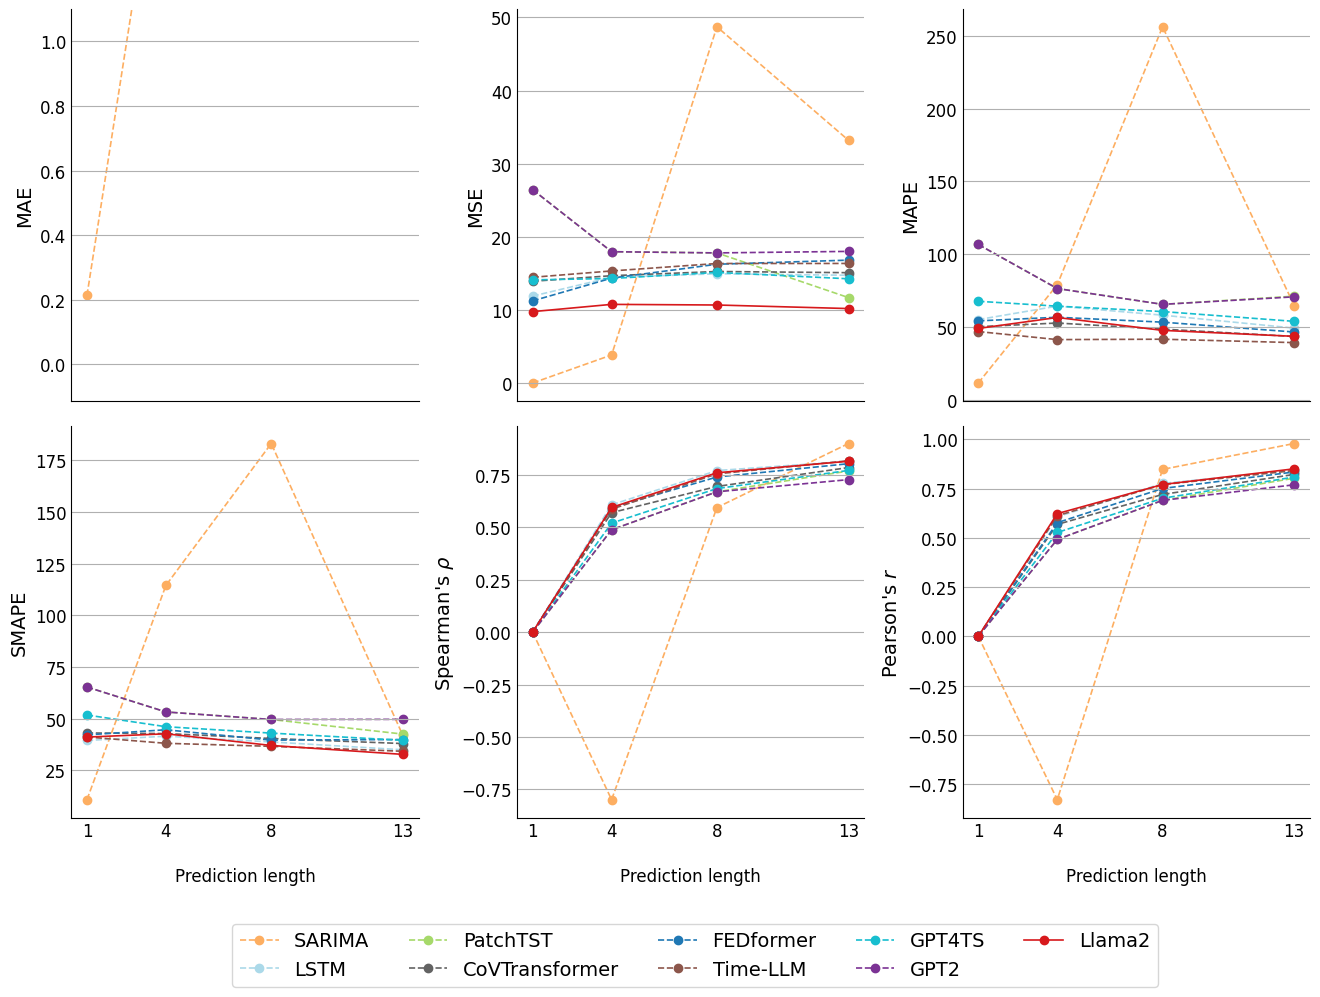

In [16]:
## 正常legend
fig, axes = plt.subplots(2, 3, figsize=(14, 10))

pred_lens = dt['pred_len'].unique()

metrics_axes = zip(metrics_visual, axes.flat)

for i, (metric, ax) in enumerate(metrics_axes):
    for model in model_order:
        subset = dt[dt['model'] == model]
        if model == 'Llama2' or model == 'GPT2(6)':
            ax.plot(subset['pred_len'], subset[metric], marker='o', label=model, color=model_colors.get(model, 'gray'), linewidth=1.2, zorder=2)
        else:
            ax.plot(subset['pred_len'], subset[metric], marker='o', linestyle='--', label=model, color=model_colors.get(model, 'gray'), linewidth=1.2, zorder=1)


    metric_label = metric_name_mapping.get(metric, metric)
    ax.set_ylabel(metric_label, fontsize=14)
    ax.grid(True, axis='y')
    # ax.set_xticks([])
    # ax.set_yticks([])
    ax.tick_params(axis='both', length=0)
    # ax.tick_params(axis='x', length=0)
    ax.tick_params(axis='both', labelsize=12)
    ax.spines['top'].set_color('none')
    ax.spines['right'].set_color('none')
    ax.set_xticks(pred_lens)
    
    if i == 0:
        ax.set_ylim(top=1.1)
    # 移除第一行子图的 x 轴刻度和标签
    if i < 3:
        ax.set_xticks([])

    if i >= 3:
        ax.text(0.5, -0.15, f'Prediction length', ha='center', va='center', transform=ax.transAxes, fontsize=12)

# fig.text(0.5, 0.035, 'Prediction length', ha='center', fontsize=14)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.03), ncol=5, fontsize=14)


plt.tight_layout(rect=[0, 0.05, 0.95, 0.95])
# plt.savefig(f"/data_disk/lichx/NeurIPS2023-One-Fits-All/Influenza_Forecasting/Output/12_6_png/comparison_of_different_pred_len_with_legend.pdf", format="pdf", bbox_inches='tight')
plt.show()


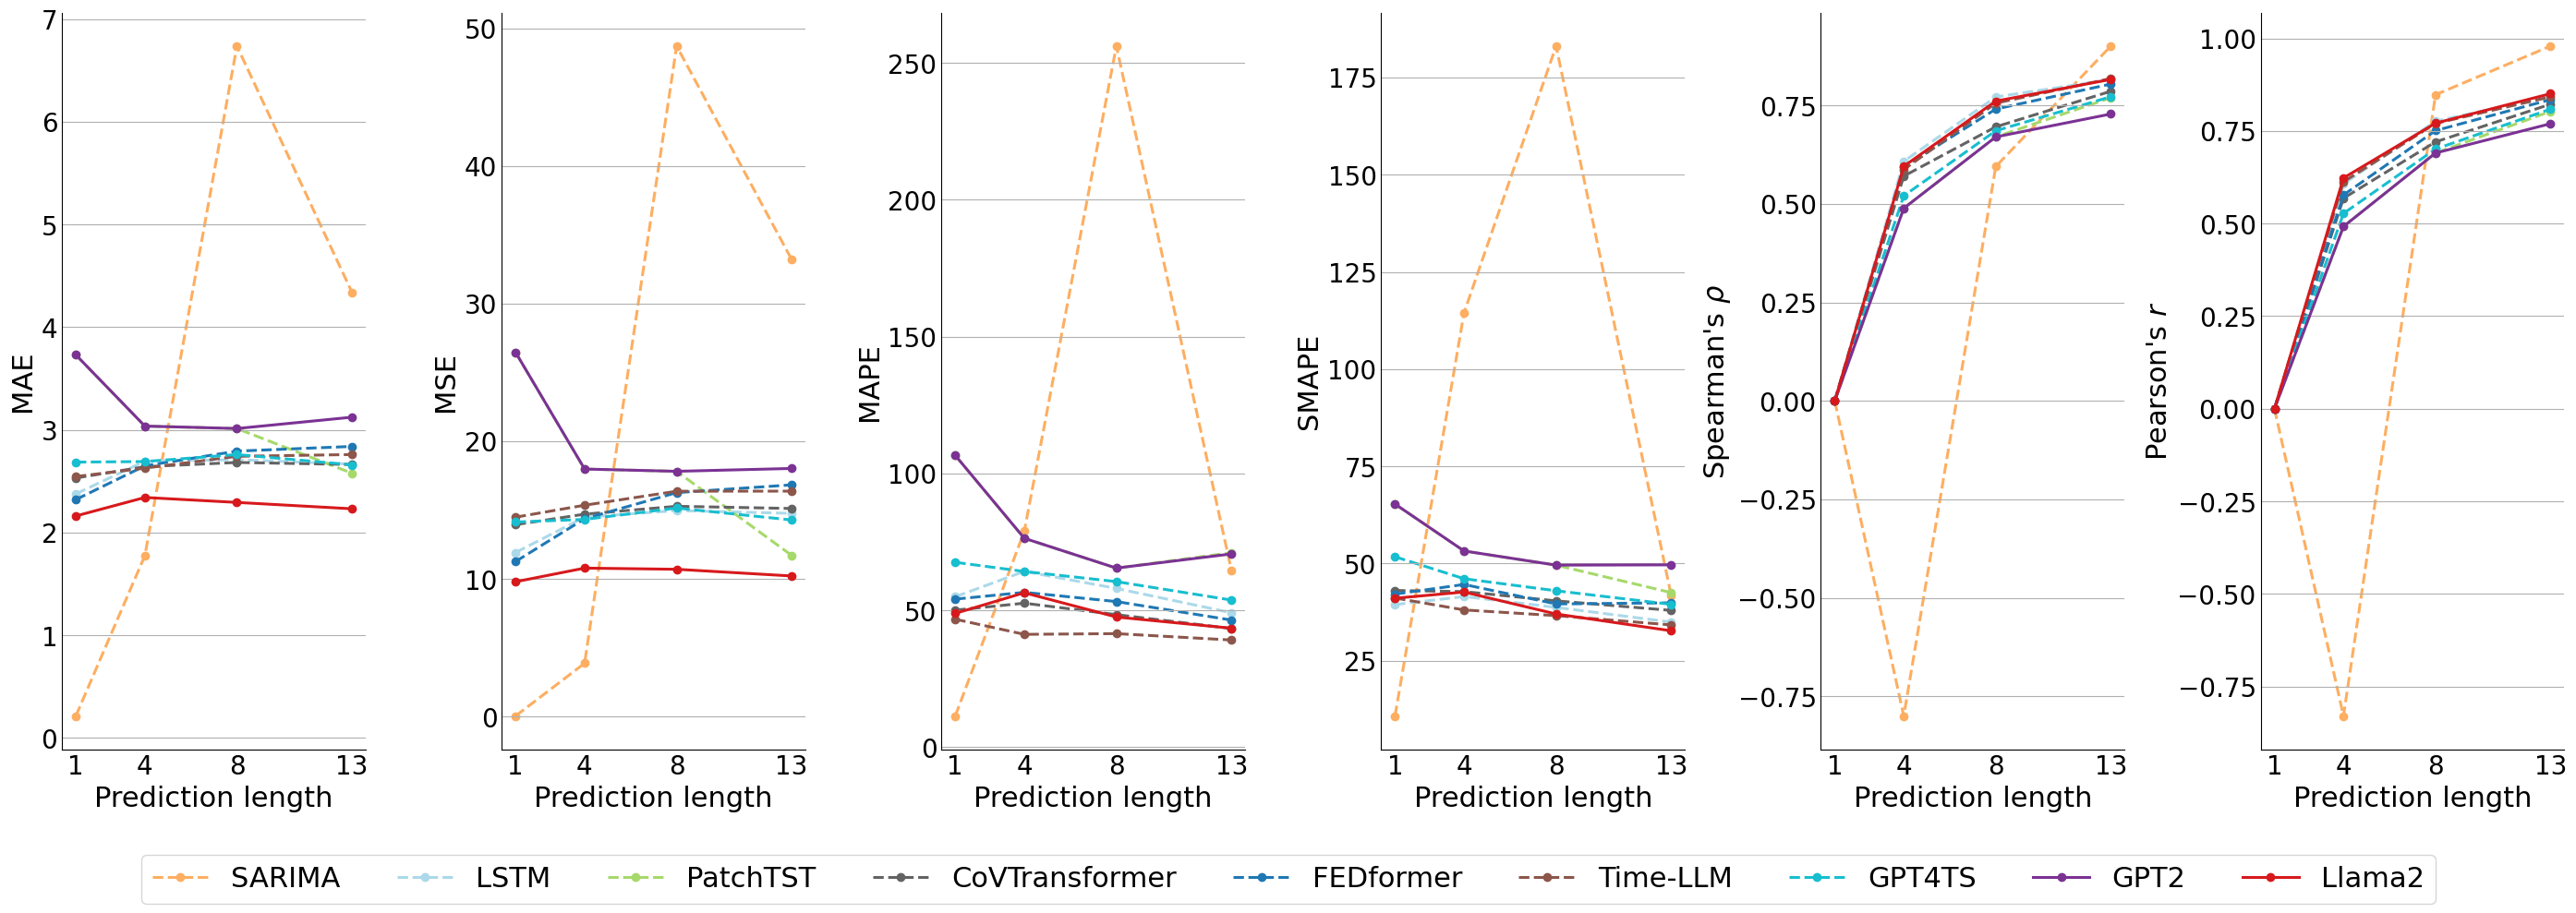

In [17]:
fig, axes = plt.subplots(1, 6, figsize=(28, 10))  # 横向排布，放大尺寸
pred_lens = dt['pred_len'].unique()

for i, (metric, ax) in enumerate(zip(metrics_visual, axes)):
    for model in model_order:
        subset = dt[dt['model'] == model]
        linestyle = '-' if model in ['Llama2', 'GPT2'] else '--'
        z = 2 if model in ['Llama2', 'GPT2'] else 1

        ax.plot(subset['pred_len'], subset[metric], marker='o',
                label=model, linestyle=linestyle,
                color=model_colors.get(model, 'gray'),
                linewidth=2.2, markersize=6, zorder=z)

    ax.set_ylabel(metric_name_mapping.get(metric, metric), fontsize=22)
    ax.set_xlabel("Prediction length", fontsize=22)
    ax.set_xticks(pred_lens)
    ax.tick_params(axis='both', length=0, labelsize=20)
    ax.grid(True, axis='y')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# 添加统一图例（底部居中）
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', bbox_to_anchor=(0.5, 0), ncol=9, fontsize=22)

plt.tight_layout(rect=[0, 0.1, 1, 1])  # 留出底部空间
plt.savefig(f"/data_disk/lichx/Predict/Influenza_Forecasting/Output/r2/comparison_of_different_pred_len_with_legend_1_6_new.pdf", format="pdf", bbox_inches='tight')

plt.show()

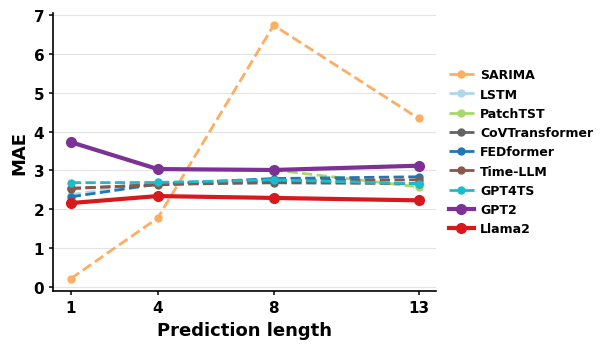

In [6]:
import matplotlib.pyplot as plt

# =========================
# 只保留第一个子图对应的 metric
# =========================
metric = metrics_visual[0]

# 预测长度
pred_lens = dt["pred_len"].unique()

# =========================
# GA 单图尺寸
# 右侧要放 legend，所以宽度稍微加大
# =========================
fig, ax = plt.subplots(figsize=(6.2, 3.6))

# =========================
# 绘制不同模型随预测长度变化的曲线
# =========================
for model in model_order:
    subset = dt[dt["model"] == model].copy()

    linestyle = "-" if model in ["Llama2", "GPT2"] else "--"
    z = 3 if model in ["Llama2", "GPT2"] else 1
    lw = 3.0 if model in ["Llama2", "GPT2"] else 2.0
    ms = 7 if model in ["Llama2", "GPT2"] else 5

    ax.plot(
        subset["pred_len"],
        subset[metric],
        marker="o",
        label=model,
        linestyle=linestyle,
        color=model_colors.get(model, "gray"),
        linewidth=lw,
        markersize=ms,
        zorder=z
    )

# =========================
# 坐标轴设置
# =========================
ax.set_ylabel(
    metric_name_mapping.get(metric, metric),
    fontsize=13,
    fontweight="bold"
)

ax.set_xlabel(
    "Prediction length",
    fontsize=13,
    fontweight="bold"
)

ax.set_xticks(pred_lens)

ax.tick_params(
    axis="both",
    length=3,
    width=1.1,
    labelsize=11
)

# 加粗刻度文字
for label in ax.get_xticklabels():
    label.set_fontweight("bold")

for label in ax.get_yticklabels():
    label.set_fontweight("bold")

# =========================
# 网格与边框
# =========================
ax.grid(True, axis="y", alpha=0.35)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.spines["left"].set_linewidth(1.2)
ax.spines["bottom"].set_linewidth(1.2)

# =========================
# Legend 放到右侧，纵向排列
# =========================
leg = ax.legend(
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    ncol=1,
    frameon=False,
    handlelength=2.0,
    handletextpad=0.5,
    borderaxespad=0.0,
    fontsize=9,
    prop={"weight": "bold", "size": 9}
)

# =========================
# 保存
# =========================
plt.tight_layout()

plt.savefig(
    "/data_disk/lichx/Predict/Influenza_Forecasting/Output/r2/comparison_pred_len_GA.pdf",
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.04,
    transparent=True
)

plt.show()
plt.close()

# 12/6

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator
import matplotlib.ticker as ticker


In [2]:
true = pd.read_csv("/data_disk/lichx/CQ_CDC/2010-2023流感数据/positive_rate_pre.csv", index_col="date")
metrics = pd.read_excel("/data_disk/lichx/Predict/Influenza_Forecasting/Output/summary/metrics_last_13_week.xlsx", sheet_name=0)
pred = pd.read_excel("/data_disk/lichx/Predict/Influenza_Forecasting/Output/summary/metrics_last_13_week.xlsx", sheet_name=1, header=0)

date = pd.to_datetime(true.index)

def get_y_offset(ax, fontsize, v_ratio=0.4):
    """
    根据字体大小和y轴范围自动计算垂直偏移量
    ratio = 单个fontsize大约占y轴多少比例，乘以一个适当放大的系数
    """
    ymin, ymax = ax.get_ylim()
    return (ymax - ymin) * (fontsize / 100) * v_ratio


In [3]:
def MAE(pred, true):
    return np.mean(np.abs(pred - true))

def MSE(pred, true):
    return np.mean((pred - true) ** 2)

def MAPE(pred, true):
    return np.mean(np.abs(100 * (pred - true) / (true +1e-8)))

def SMAPE(pred, true):
    return np.mean(200 * np.abs(pred - true) / (np.abs(pred) + np.abs(true) + 1e-8))    

def metric(pred, true):
    mae = MAE(pred, true)
    mse = MSE(pred, true)
    mape = MAPE(pred, true)
    smape = SMAPE(pred, true)

    return mae, mse, mape, smape


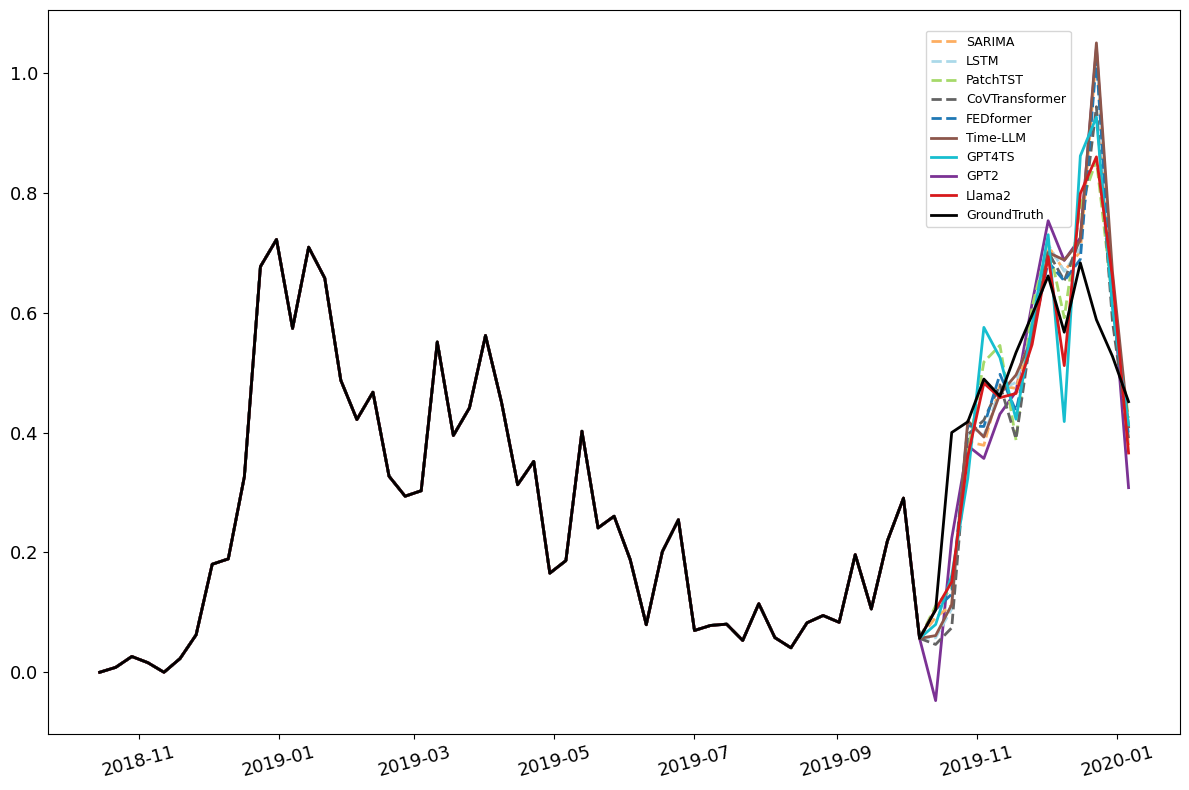

In [8]:
GT = true.iloc[-65:-13].values.reshape(-1)
# 预测值
Llama2 = pred.iloc[:, 0].values
GPT2 = pred.iloc[:, 1].values
SARIMA = pred.iloc[:, 2].values
LSTM = pred.iloc[:, 3].values
PatchTST = pred.iloc[:, 4].values
CovT = pred.iloc[:, 5].values
FEDF = pred.iloc[:, 6].values
TimeLLM = pred.iloc[:, 7].values
GPT4TS = pred.iloc[:, 8].values

Llama2_full = np.concatenate([GT, Llama2])
GPT2_full = np.concatenate([GT, GPT2])
SARIMA_full = np.concatenate([GT, SARIMA])
LSTM_full = np.concatenate([GT, LSTM])
PatchTST_full = np.concatenate([GT, PatchTST])
CovT_full = np.concatenate([GT, CovT])
FEDF_full = np.concatenate([GT, FEDF])
TimeLLM_full = np.concatenate([GT, TimeLLM])
GPT4TS_full = np.concatenate([GT, GPT4TS])

plt.figure(figsize=(12, 8))

plt.plot(date.values[-65:], SARIMA_full, label=pred.columns[2], color='#fdae61', linestyle='--', linewidth=2, alpha=1, zorder=3)
plt.plot(date.values[-65:], LSTM_full, label=pred.columns[3], color='#abd9e9', linestyle='--', linewidth=2, alpha=1, zorder=3)
plt.plot(date.values[-65:], PatchTST_full, label=pred.columns[4], color='#a6d96a', linestyle='--', linewidth=2, alpha=1, zorder=3)
plt.plot(date.values[-65:], CovT_full, label='CoVTransformer', color='#636363', linestyle='--', linewidth=2, alpha=1, zorder=3)
plt.plot(date.values[-65:], FEDF_full, label='FEDformer', color='#1f78b4', linestyle='--', linewidth=2, alpha=1, zorder=3)
plt.plot(date.values[-65:], TimeLLM_full, label='Time-LLM', color='#8c564b', linewidth=2, alpha=1, zorder=3)
plt.plot(date.values[-65:], GPT4TS_full, label='GPT4TS', color='#17becf', linewidth=2, alpha=1, zorder=3)
plt.plot(date.values[-65:], GPT2_full, label=pred.columns[1], color='#7b3294', linewidth=2, alpha=1)
plt.plot(date.values[-65:], Llama2_full, label=pred.columns[0], color='#d7191c', linewidth=2, alpha=1, zorder=3)

# 绘制真实值
plt.plot(date.values[-65:], true.iloc[-65:].values.reshape(-1), label="GroundTruth", color='black', linewidth=2, alpha=1, zorder=3)
plt.xticks(fontsize=13, rotation=15)
plt.yticks(fontsize=13)
# 显示图例
leg = plt.legend(loc='upper left', bbox_to_anchor=(0.77, 0.98), frameon=True, fontsize=9)
leg.set_zorder(0)
plt.tight_layout()

# 显示图形
plt.savefig("/data_disk/lichx/Predict/Influenza_Forecasting/Output/r2/pred_new.pdf", format="pdf", bbox_inches='tight')
plt.show()
plt.close()

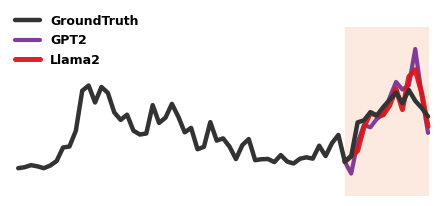

In [13]:
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. 提取真实值和预测值
# =========================

# 历史真实值：前 52 周
GT = true.iloc[-65:-13].values.reshape(-1)

# 未来 13 周预测值
Llama2 = pred.iloc[:, 0].values
GPT2 = pred.iloc[:, 1].values

# 完整真实值：52 周历史 + 13 周未来真实值
GroundTruth_full = true.iloc[-65:].values.reshape(-1)

# =========================
# 2. 构造横坐标
# =========================

# 完整真实值横坐标：0~64，共 65 个点
x_full = np.arange(len(GroundTruth_full))

# 预测线为了自然衔接，从最后一个历史点开始画
# 即从第 51 个点开始，后面接 13 个预测点，共 14 个点
x_forecast = np.arange(51, 65)

# 在预测值前面补上最后一个历史真实点，实现自然连接
GPT2_plot = np.concatenate([[GT[-1]], GPT2])
Llama2_plot = np.concatenate([[GT[-1]], Llama2])

# =========================
# 3. 颜色和样式设置
# =========================

groundtruth_color = "#333333"
gpt2_color = "#7B3294"
llama2_color = "#D7191C"
forecast_bg_color = "#FCE4D6"

# 适合放进 GA 右上角小框
plt.figure(figsize=(5.5, 2.2))

# =========================
# 4. 未来 13 周区域背景
# =========================

plt.axvspan(
    51,
    64,
    color=forecast_bg_color,
    alpha=0.75,
    zorder=0
)

# =========================
# 5. 绘制完整真实值
# =========================

plt.plot(
    x_full,
    GroundTruth_full,
    label="GroundTruth",
    color=groundtruth_color,
    linewidth=3.2,
    alpha=1,
    zorder=5,
    solid_capstyle="round",
    solid_joinstyle="round"
)

# =========================
# 6. 绘制 GPT2 预测线（自然衔接）
# =========================

plt.plot(
    x_forecast,
    GPT2_plot,
    label="GPT2",
    color=gpt2_color,
    linewidth=3.0,
    alpha=0.95,
    zorder=3,
    solid_capstyle="round",
    solid_joinstyle="round"
)

# =========================
# 7. 绘制 Llama2 预测线（自然衔接）
# =========================

plt.plot(
    x_forecast,
    Llama2_plot,
    label="Llama2",
    color=llama2_color,
    linewidth=3.6,
    alpha=0.95,
    zorder=4,
    solid_capstyle="round",
    solid_joinstyle="round"
)

# =========================
# 8. 去掉坐标轴，保留 legend
# =========================

plt.axis("off")
plt.margins(x=0.02, y=0.18)

leg = plt.legend(
    loc="upper left",
    bbox_to_anchor=(0.00, 1.10),
    frameon=False,
    handlelength=2.0,
    borderaxespad=0.0,
    prop={"weight": "bold", "size": 9}
)
leg.set_zorder(10)
leg.set_zorder(10)

# =========================
# 9. 保存
# =========================

plt.savefig(
    "/data_disk/lichx/Predict/Influenza_Forecasting/Output/r2/pred_gpt2_llama2_GA_forecast_natural.pdf",
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.02,
    transparent=True
)

plt.show()
plt.close()

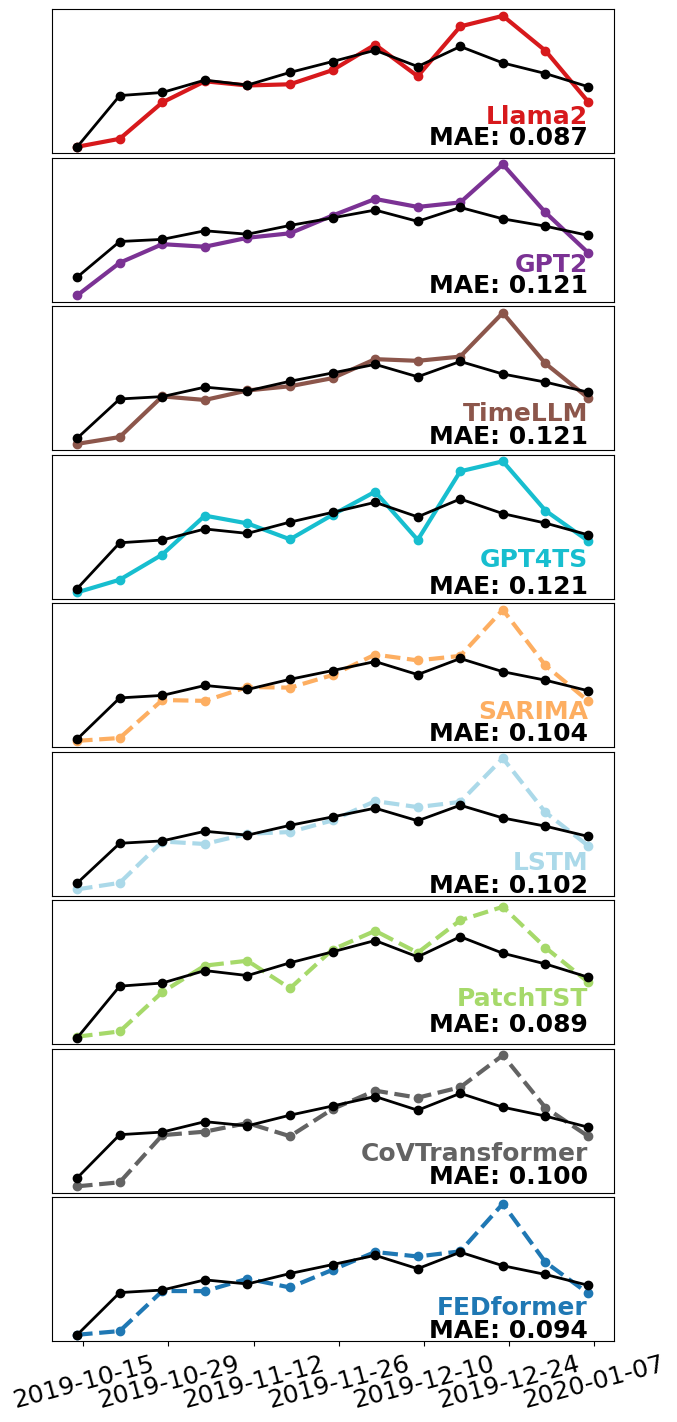

In [44]:
GT = true.iloc[-13:].values.reshape(-1)

metric = 'MAE'
ratio = 0.6
# 创建5个子图
fig, axes = plt.subplots(9, 1, figsize=(7.25, 17.3), sharex=True)

fontsize = 18
# Llama2 Prediction
axes[0].plot(date.values[-13:], Llama2, marker='o', label=pred.columns[0], color='#d7191c', linewidth=3, alpha=1)
axes[0].plot(date.values[-13:], GT, marker='o', label="GroundTruth", color='black', linewidth=2, alpha=1)
y_offset = get_y_offset(axes[0], fontsize)
axes[0].text(date.values[-1], Llama2[-1]*ratio + y_offset, "Llama2", color='#d7191c', fontsize=fontsize, ha='right', va='center', fontweight='bold')
axes[0].text(date.values[-1], Llama2[-1]*ratio - y_offset, f"MAE: {metrics[f'{metric}'][0]:.3f}", color='black', fontsize=fontsize, ha='right', va='center', fontweight='bold')
axes[0].set_xticklabels([])
axes[0].tick_params(axis='x', which='both', bottom=False, top=False)
axes[0].set_yticks([])
axes[0].set_yticklabels([])

# GPT2(6) Prediction
axes[1].plot(date.values[-13:], GPT2, marker='o', label=pred.columns[1], color='#7b3294', linewidth=3, alpha=1)
axes[1].plot(date.values[-13:], GT, marker='o', label="GroundTruth", color='black', linewidth=2, alpha=1)
y_offset = get_y_offset(axes[1], fontsize)
axes[1].text(date.values[-1], GPT2[-1]*0.4 + y_offset, "GPT2", color='#7b3294', fontsize=fontsize, ha='right', va='center', fontweight='bold')
axes[1].text(date.values[-1], GPT2[-1]*0.4 - y_offset, f"MAE: {metrics[f'{metric}'][1]:.3f}", color='black', fontsize=fontsize, ha='right', va='center', fontweight='bold')
axes[1].set_xticklabels([])
axes[1].tick_params(axis='x', which='both', bottom=False, top=False)
axes[1].set_yticks([])
axes[1].set_yticklabels([])

# TimeLLM Prediction
axes[2].plot(date.values[-13:], TimeLLM, marker='o', label=pred.columns[1], color='#8c564b', linewidth=3, alpha=1)
axes[2].plot(date.values[-13:], GT, marker='o', label="GroundTruth", color='black', linewidth=2, alpha=1)
y_offset = get_y_offset(axes[1], fontsize)
axes[2].text(date.values[-1], TimeLLM[-1]*0.5 + y_offset, "TimeLLM", color='#8c564b', fontsize=fontsize, ha='right', va='center', fontweight='bold')
axes[2].text(date.values[-1], TimeLLM[-1]*0.5 - y_offset, f"MAE: {metrics[f'{metric}'][1]:.3f}", color='black', fontsize=fontsize, ha='right', va='center', fontweight='bold')
axes[2].set_xticklabels([])
axes[2].tick_params(axis='x', which='both', bottom=False, top=False)
axes[2].set_yticks([])
axes[2].set_yticklabels([])

# GPT4TS Prediction
axes[3].plot(date.values[-13:], GPT4TS, marker='o', label=pred.columns[1], color='#17becf', linewidth=3, alpha=1)
axes[3].plot(date.values[-13:], GT, marker='o', label="GroundTruth", color='black', linewidth=2, alpha=1)
y_offset = get_y_offset(axes[1], fontsize)
axes[3].text(date.values[-1], GPT4TS[-1]*0.5 + y_offset, "GPT4TS", color='#17becf', fontsize=fontsize, ha='right', va='center', fontweight='bold')
axes[3].text(date.values[-1], GPT4TS[-1]*0.5 - y_offset, f"MAE: {metrics[f'{metric}'][1]:.3f}", color='black', fontsize=fontsize, ha='right', va='center', fontweight='bold')
axes[3].set_xticklabels([])
axes[3].tick_params(axis='x', which='both', bottom=False, top=False)
axes[3].set_yticks([])
axes[3].set_yticklabels([])

# SARIMA Prediction
axes[4].plot(date.values[-13:], SARIMA, marker='o', label=pred.columns[2], color='#fdae61', linestyle='--', linewidth=3, alpha=1)
axes[4].plot(date.values[-13:], GT, marker='o', label="GroundTruth", color='black', linewidth=2, alpha=1)
y_offset = get_y_offset(axes[2], fontsize)
axes[4].text(date.values[-1], SARIMA[-1]*ratio + y_offset, "SARIMA", color='#fdae61', fontsize=fontsize, ha='right', va='center', fontweight='bold')
axes[4].text(date.values[-1], SARIMA[-1]*ratio - y_offset, f"MAE: {metrics[f'{metric}'][2]:.3f}", color='black', fontsize=fontsize, ha='right', va='center', fontweight='bold')
axes[4].set_xticklabels([])
axes[4].tick_params(axis='x', which='both', bottom=False, top=False)
axes[4].set_yticks([])
axes[4].set_yticklabels([])

# LSTM Prediction
axes[5].plot(date.values[-13:], LSTM, marker='o', label=pred.columns[3], color='#abd9e9', linestyle='--', linewidth=3, alpha=1)
axes[5].plot(date.values[-13:], GT, marker='o', label="GroundTruth", color='black', linewidth=2, alpha=1)
y_offset = get_y_offset(axes[3], fontsize)
axes[5].text(date.values[-1], LSTM[-1]*0.5 + y_offset, "LSTM", color='#abd9e9', fontsize=fontsize, ha='right', va='center', fontweight='bold')
axes[5].text(date.values[-1], LSTM[-1]*0.4 - y_offset, f"MAE: {metrics[f'{metric}'][3]:.3f}", color='black', fontsize=fontsize, ha='right', va='center', fontweight='bold')
axes[5].set_xticklabels([])
axes[5].tick_params(axis='x', which='both', bottom=False, top=False)
axes[5].set_yticks([])
axes[5].set_yticklabels([])

# PatchTST Prediction
axes[6].plot(date.values[-13:], PatchTST, marker='o', label=pred.columns[4], color='#a6d96a', linestyle='--', linewidth=3, alpha=1)
axes[6].plot(date.values[-13:], GT, marker='o', label="GroundTruth", color='black', linewidth=2, alpha=1)
y_offset = get_y_offset(axes[4], fontsize)
axes[6].text(date.values[-1], PatchTST[-1]*ratio + y_offset, "PatchTST", color='#a6d96a', fontsize=fontsize, ha='right', va='center', fontweight='bold')
axes[6].text(date.values[-1], PatchTST[-1]*ratio - y_offset, f"MAE: {metrics[f'{metric}'][4]:.3f}", color='black', fontsize=fontsize, ha='right', va='center', fontweight='bold')
axes[6].set_xticklabels([])
axes[6].tick_params(axis='x', which='both', bottom=False, top=False)
axes[6].set_yticks([])
axes[6].set_yticklabels([])

# CovT Prediction
axes[7].plot(date.values[-13:], CovT, marker='o', label=pred.columns[5], color='#636363', linestyle='--', linewidth=3, alpha=1)
axes[7].plot(date.values[-13:], GT, marker='o', label="GroundTruth", color='black', linewidth=2, alpha=1)
y_offset = get_y_offset(axes[5], fontsize)
axes[7].text(date.values[-1], CovT[-1]*0.5 + y_offset, "CoVTransformer", color='#636363', fontsize=fontsize, ha='right', va='center', fontweight='bold')
axes[7].text(date.values[-1], CovT[-1]*0.5 - y_offset, f"MAE: {metrics[f'{metric}'][5]:.3f}", color='black', fontsize=fontsize, ha='right', va='center', fontweight='bold')
axes[7].set_xticklabels([])
axes[7].tick_params(axis='x', which='both', bottom=False, top=False)
axes[7].set_yticks([])
axes[7].set_yticklabels([])

# FEDF Prediction
axes[8].plot(date.values[-13:], FEDF, marker='o', label=pred.columns[6], color='#1f78b4', linestyle='--', linewidth=3, alpha=1)
axes[8].plot(date.values[-13:], GT, marker='o', label="GroundTruth", color='black', linewidth=2, alpha=1)
y_offset = get_y_offset(axes[6], fontsize)
axes[8].text(date.values[-1], FEDF[-1]*0.6 + y_offset, "FEDformer", color='#1f78b4', fontsize=fontsize, ha='right', va='center', fontweight='bold')
axes[8].text(date.values[-1], FEDF[-1]*0.5 - y_offset, f"MAE: {metrics[f'{metric}'][6]:.3f}", color='black', fontsize=fontsize, ha='right', va='center', fontweight='bold')
axes[8].tick_params(axis='x', labelsize=fontsize)
axes[8].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
axes[8].xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))
axes[8].set_yticks([])
axes[8].set_yticklabels([])

for tick in axes[8].get_xticklabels():
    tick.set_rotation(15) 

plt.subplots_adjust(hspace=0.03)
# plt.tight_layout()

plt.savefig("/data_disk/lichx/Predict/Influenza_Forecasting/Output/r2/All_Model_Predictions_with_legend_new.pdf", bbox_inches='tight')
plt.show()


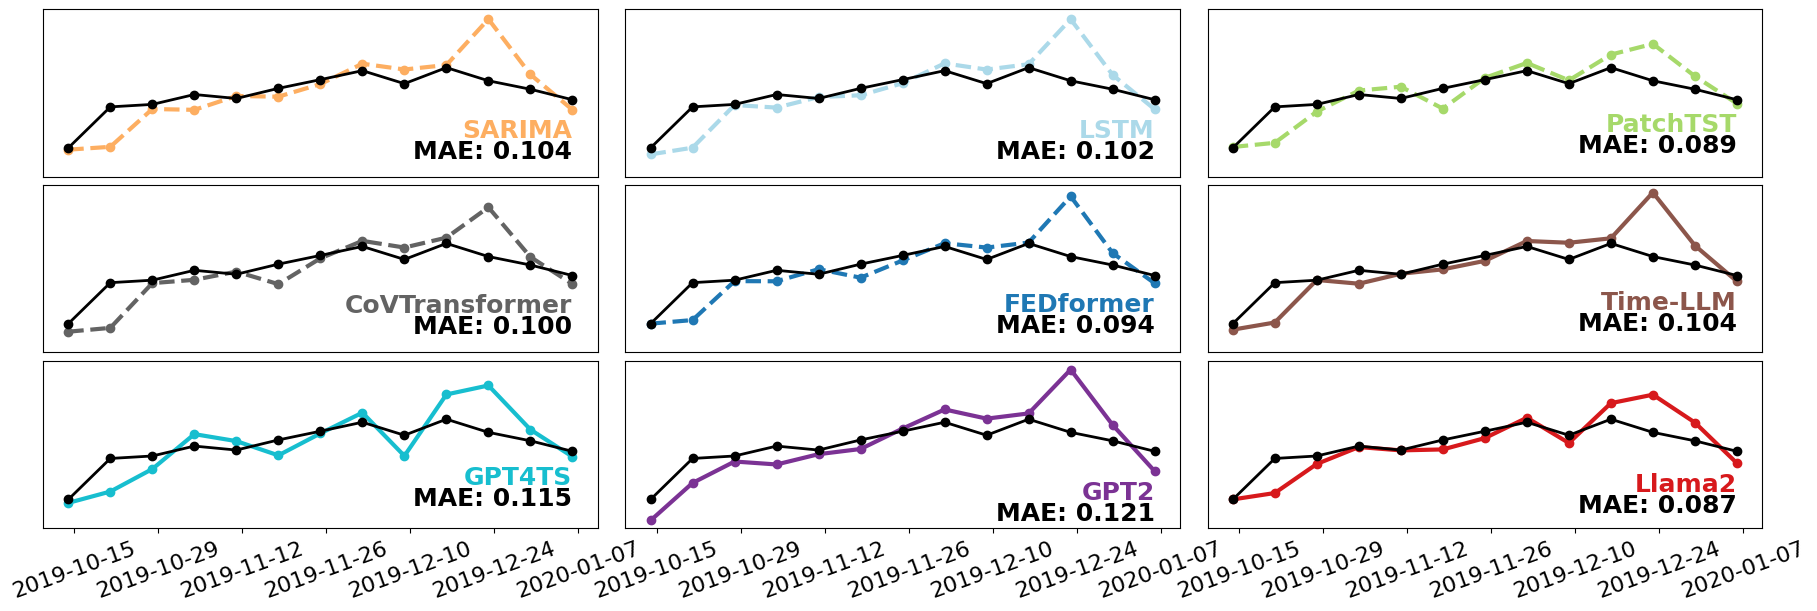

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ========= 数据 =========
x = pd.to_datetime(date.values[-13:])
GT = true.iloc[-13:].values.reshape(-1)

metric = "MAE"
fontsize = 18

def calc_mae(y_pred, y_true):
    y_pred = np.asarray(y_pred, dtype=float).reshape(-1)
    y_true = np.asarray(y_true, dtype=float).reshape(-1)
    return float(np.mean(np.abs(y_pred - y_true)))

# ========= 模型配置（按你希望的顺序） =========
model_specs = [
    dict(name="SARIMA",         y=SARIMA,  color="#fdae61", ls="--"),
    dict(name="LSTM",           y=LSTM,    color="#abd9e9", ls="--"),
    dict(name="PatchTST",       y=PatchTST,color="#a6d96a", ls="--"),
    dict(name="CoVTransformer", y=CovT,    color="#636363", ls="--"),
    dict(name="FEDformer",      y=FEDF,    color="#1f78b4", ls="--"),
    dict(name="Time-LLM",        y=TimeLLM, color="#8c564b", ls="-"),
    dict(name="GPT4TS",         y=GPT4TS,  color="#17becf", ls="-"),
    dict(name="GPT2",           y=GPT2,    color="#7b3294", ls="-"),
    dict(name="Llama2",         y=Llama2,  color="#d7191c", ls="-")
]

# ========= 3x3 布局 =========
nrows, ncols = 3, 3
fig, axes = plt.subplots(3, 3, figsize=(18, 6), sharex=True, constrained_layout=False)
axes = axes.flatten()

# 先算全局 y 轴范围（放到 for 循环之前）
all_series = [GT] + [np.asarray(s["y"]).reshape(-1) for s in model_specs]
ymin = min(np.min(s) for s in all_series)
ymax = max(np.max(s) for s in all_series)
pad = 0.05 * (ymax - ymin + 1e-12)

for i, spec in enumerate(model_specs):
    ax = axes[i]
    y_pred = np.asarray(spec["y"]).reshape(-1)

    # 预测 + GT
    ax.plot(x, y_pred, marker="o", color=spec["color"], linestyle=spec["ls"],
            linewidth=3, alpha=1)
    ax.plot(x, GT, marker="o", color="black", linewidth=2, alpha=1)

    # 文本（模型名 + MAE）
    mae = calc_mae(y_pred, GT)
    y_offset = get_y_offset(ax, fontsize)  # 你已有的函数

    ax.text(x[-1], y_pred[-1] - 0.15, spec["name"],
            color=spec["color"], fontsize=fontsize, ha="right", va="center",
            fontweight="bold")
    ax.text(x[-1], y_pred[-1] - 0.3, f"{metric}: {mae:.3f}",
            color="black", fontsize=fontsize, ha="right", va="center",
            fontweight="bold")

    # y 轴隐藏
    ax.set_yticks([])
    ax.set_yticklabels([])
    ax.grid(False)

    # 非底行不显示 x tick 标签（减少拥挤）
    if i < (nrows - 1) * ncols:  # 前两行
        ax.tick_params(axis="x", which="both", bottom=False, labelbottom=False)
    else:
        ax.tick_params(axis="x", labelsize=16)

for ax in axes:
    if ax.axison:
        ax.set_ylim(ymin - pad, ymax + pad)

# x 轴日期格式（sharex=True 会同步）
for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=2))

# 仅底行旋转刻度
for ax in axes[(nrows - 1) * ncols:]:
    for t in ax.get_xticklabels():
        t.set_rotation(20)

# 子图间距：避免文本和线条挤在一起
# plt.subplots_adjust(wspace=0.25, hspace=0.28)
plt.subplots_adjust(left=0.04, right=0.995, top=0.985, bottom=0.12,
                    wspace=0.05, hspace=0.05)


plt.savefig(
    "/data_disk/lichx/Predict/Influenza_Forecasting/Output/r2/All_Model_Predictions_33.pdf",
    # bbox_inches="tight"
    dpi=300
)
plt.show()
plt.close()


## 12/30 Zero-Shot

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [11]:
data_raw = pd.read_excel("/data_disk/lichx/NeurIPS2023-One-Fits-All/Influenza_Forecasting/Output/汇总.xlsx", sheet_name=3)
metric = 'spearmanR'
data = data_raw[["dataset", "model", metric]]

# 创建 x 轴偏移，用于将同一个数据集下的不同模型分开
data["x_positions"] = (
    data["dataset"].astype("category").cat.codes +
    data["model"].map({"Llama2": -0.2, "GPT2": 0, "PatchTST": 0.2})
)

/tmp/ipykernel_4273/475324804.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["x_positions"] = (


In [12]:
dataset_rename_map = {
    "USAFlu": "USA Flu",
    "SouthChinaFlu": "Southern Flu",
    "NorthChinaFlu": "Northern Flu",
    "NorthChinaILI": "Northern ILI",
    "SouthChinaILI": "Southern ILI",
    "Weekly": "Chongqing ILI",
    "PositiveRate": "Chongqing Flu"
}

desired_order = [
    "Southern Flu",
    "Northern Flu",
    "Chongqing Flu",
    "USA Flu",
    "Southern ILI",
    "Northern ILI",
    "Chongqing ILI"
]

data["dataset"] = data["dataset"].map(dataset_rename_map)
data["dataset"] = pd.Categorical(data["dataset"], categories=desired_order, ordered=True)
data["x_positions"] = data["dataset"].cat.codes + data["model"].map({"Llama2": -0.2, "GPT2": 0, "PatchTST": 0.2})


/tmp/ipykernel_4273/3445692536.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["dataset"] = data["dataset"].map(dataset_rename_map)
/tmp/ipykernel_4273/3445692536.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["dataset"] = pd.Categorical(data["dataset"], categories=desired_order, ordered=True)
/tmp/ipykernel_4273/3445692536.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the c

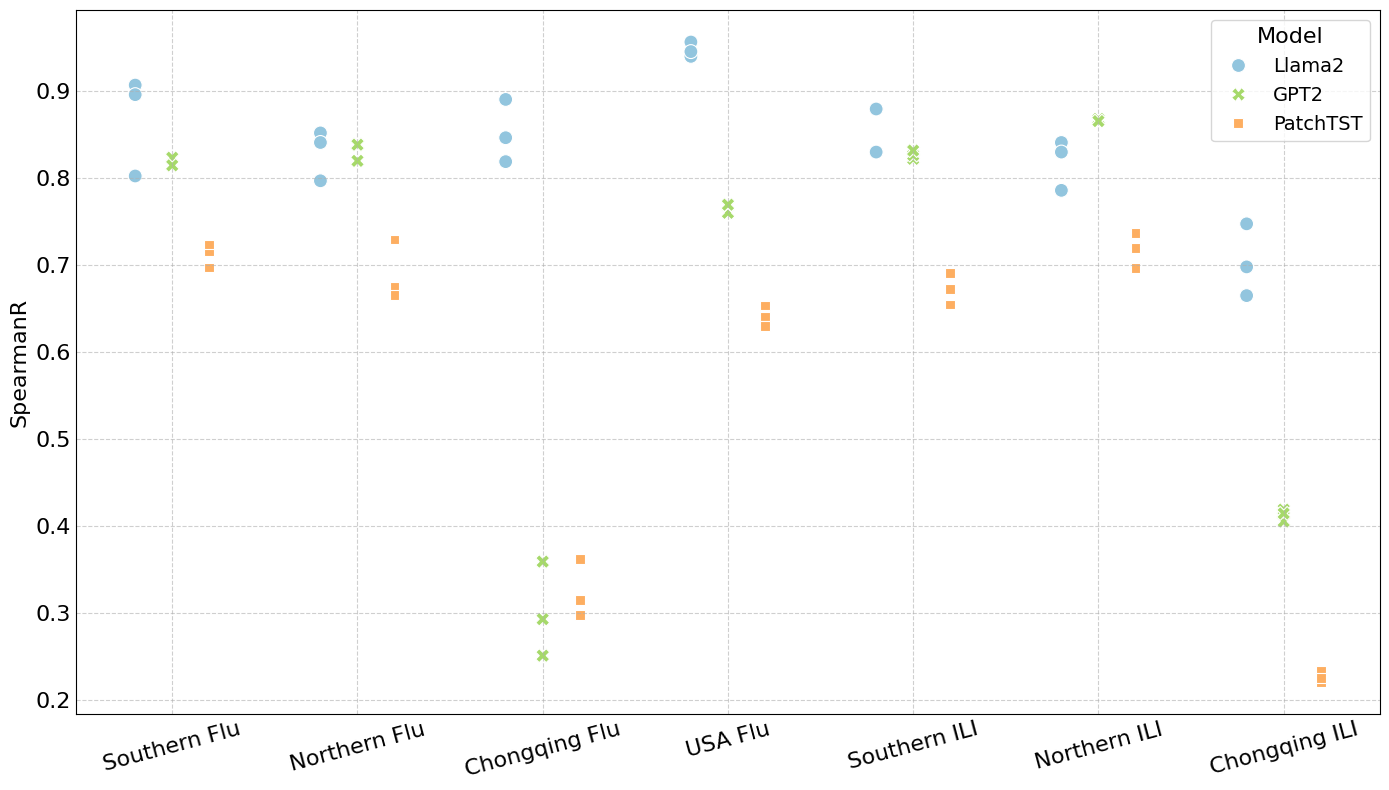

In [13]:
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=data,
    x="x_positions",
    y="spearmanR",
    hue="model",
    style="model",
    palette={"Llama2": "#92c5de", "GPT2": "#a6d96a", "PatchTST": "#fdae61"},
    s=100
)

# 更新 x 轴刻度和标签
plt.xticks(
    ticks=range(len(data["dataset"].unique())),
    labels=desired_order,
    rotation=15,
    fontsize=16
)

plt.gca().tick_params(axis='x', length=0)  # 去掉 x 轴刻度线
plt.gca().tick_params(axis='y', length=0)  # 去掉 y 轴刻度线
plt.xlabel("", fontsize=16)
plt.ylabel("SpearmanR", fontsize=16)
plt.yticks(fontsize=16)
plt.legend(title="Model", fontsize=14, title_fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.savefig("/data_disk/lichx/NeurIPS2023-One-Fits-All/Influenza_Forecasting/Output/12_30_png/zero_shot_2.pdf", bbox_inches='tight')
plt.show()

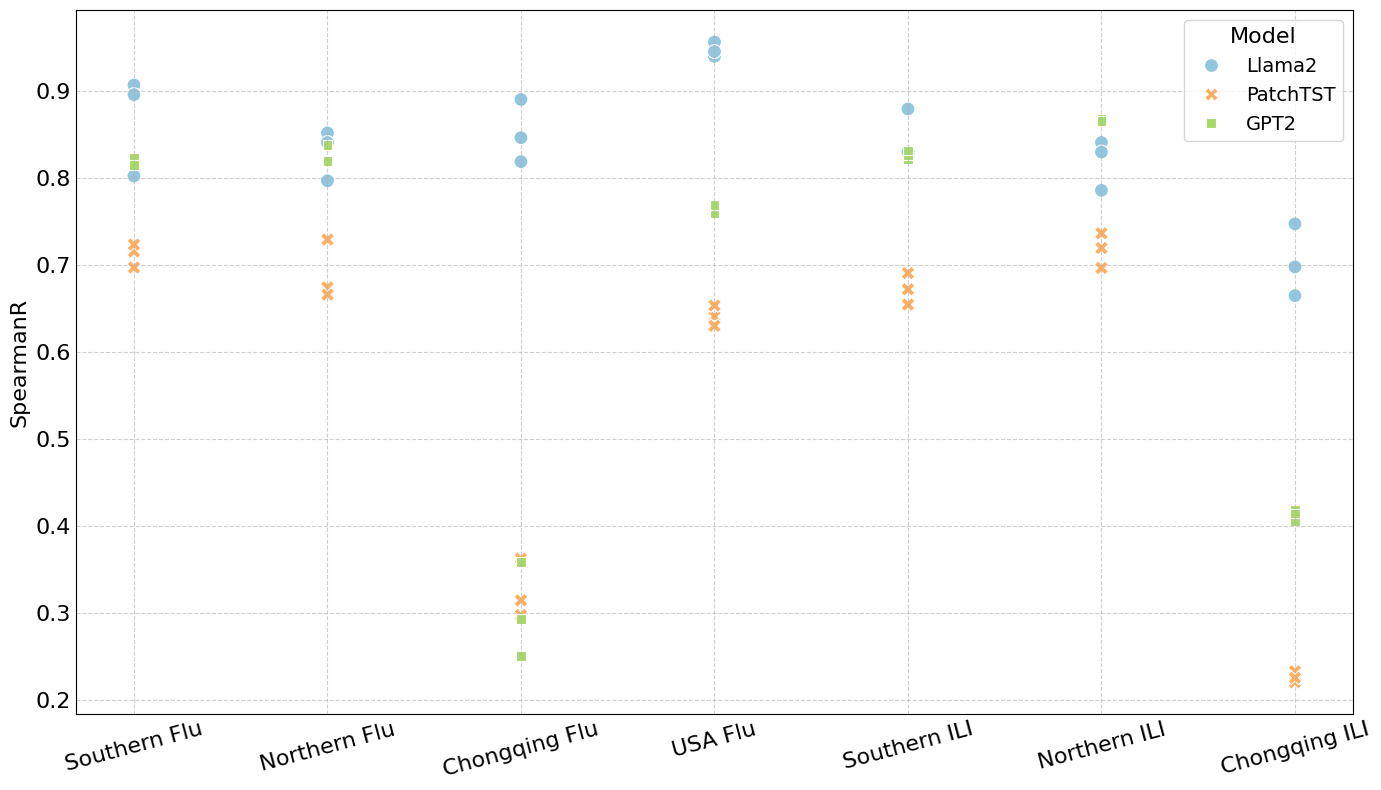

In [18]:
# 绘制散点图，同一个数据集的点保持在同一条线上
plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=data,
    x="dataset",
    y="spearmanR",
    hue="model",
    style="model",
    markers=True,
    palette={"Llama2": "#92c5de", "PatchTST": "#fdae61", "GPT2": "#a6d96a"},
    s=100
)

plt.gca().tick_params(axis='x', length=0)
plt.gca().tick_params(axis='y', length=0)
plt.xlabel("", fontsize=16)
plt.ylabel("SpearmanR", fontsize=16)
plt.xticks(rotation=15, fontsize=16)
plt.yticks(fontsize=16)
plt.legend(title="Model", fontsize=14, title_fontsize=16)
plt.grid(True, linestyle='--', alpha=0.6)

# 显示图表
plt.tight_layout()
plt.savefig("/data_disk/lichx/NeurIPS2023-One-Fits-All/Influenza_Forecasting/Output/12_30_png/zero_shot_2.pdf", bbox_inches='tight')
plt.show()


# 4/18

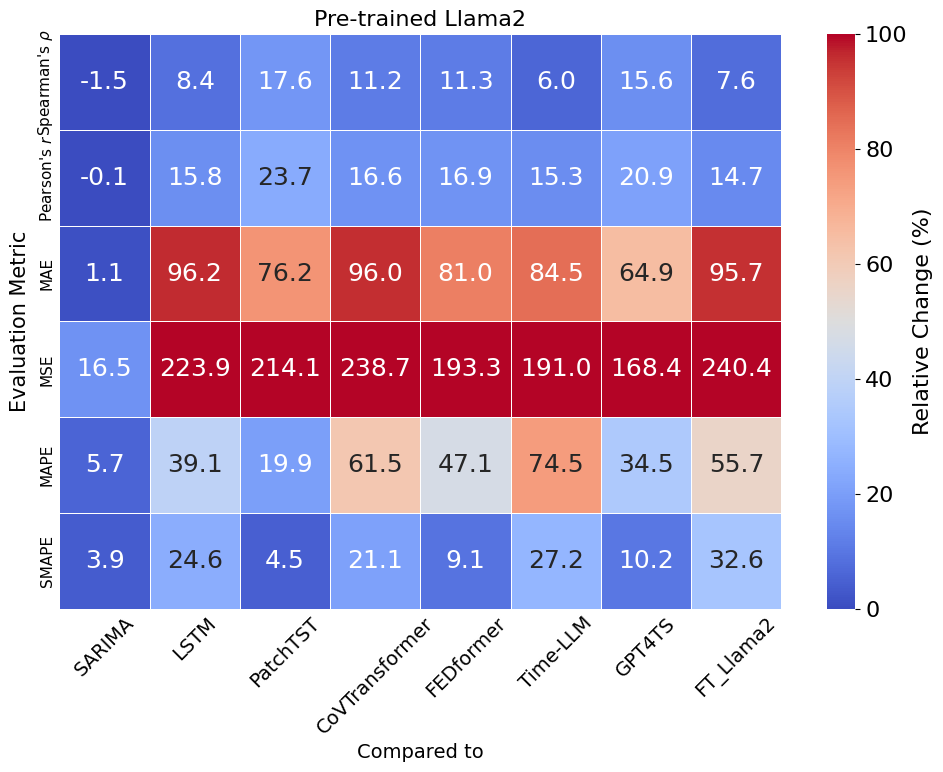

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# === 构造数据 ===
data = {
    'SARIMA':    [-1.54, -0.10, 1.06, 16.50, 5.68, 3.87],
    'LSTM':      [8.36, 15.81, 96.25, 223.9, 39.08, 24.57],
    'PatchTST':  [17.62, 23.71, 76.18, 214.1, 19.94, 4.52],
    'CoVTransformer':      [11.20, 16.59, 95.99, 238.7, 61.52, 21.08],
    'FEDformer':      [11.28, 16.94, 80.97, 193.3, 47.12, 9.10],
    'Time-LLM':  [6.02, 15.29, 84.52, 191.0, 74.50, 27.20],
    'GPT4TS':   [15.64, 20.87, 64.92, 168.4, 34.49, 10.15],
    'FT_Llama2': [7.61, 14.71, 95.67, 240.4, 55.72, 32.58]
}

metrics = [r"Spearman's $\it{\rho}$", r"Pearson's $\it{r}$", "MAE", "MSE", "MAPE", "SMAPE"]
df = pd.DataFrame(data, index=metrics)
df.index.name = "Evaluation Metric"

# === 自定义颜色：从白色到红色 ===
red_cmap = LinearSegmentedColormap.from_list("custom_red", ["#619DB8", "#C85D4D"])  

# === 设置色阶 ===
vmin = 0
# vmax = df[df > 0].max().max()  # 只考虑正值作为最大色阶
vmax = 100  # 只考虑正值作为最大色阶

# === 绘图 ===
plt.figure(figsize=(10, 8))  
ax = sns.heatmap(
    df,
    annot=True,
    fmt=".1f",
    # cmap=red_cmap,
    cmap="coolwarm",
    vmin=vmin,
    vmax=vmax,
    cbar_kws={'label': ''},
    linewidths=0.5,
    linecolor='white',
    annot_kws={"size": 18}
)

ax.collections[0].colorbar.ax.set_ylabel("Relative Change (%)", fontsize=16)
ax.tick_params(axis='both', length=0)

plt.title("Pre-trained Llama2", fontsize=16)
ax.set_ylabel("Evaluation Metric", fontsize=15)
ax.set_xlabel("Compared to", fontsize=14)
plt.xticks(rotation=45, fontsize=14)
plt.yticks(rotation=90, fontsize=11)

plt.tight_layout()
plt.savefig("/data_disk/lichx/Predict/Influenza_Forecasting/Output/r2/llama2_relative_improvement_heatmap_new.pdf")
plt.show()


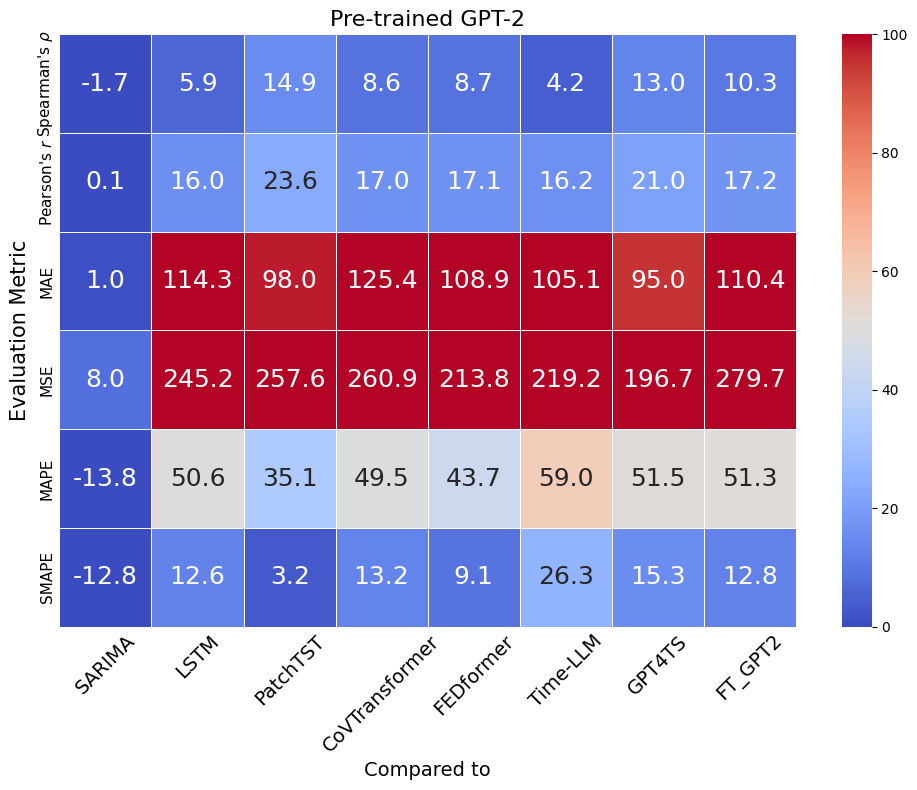

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap, to_hex, TwoSlopeNorm

# === 构造数据 ===
data = {
    'SARIMA':    [-1.74, 0.11, 0.96, 8.00, -13.82, -12.77],
    'LSTM':      [5.87, 16.00, 114.27, 245.2, 50.59, 12.59],
    'PatchTST':  [14.91, 23.58, 98.02, 257.55, 35.09, 3.25],
    'CoVTransformer':      [8.62,16.99, 125.4, 260.9, 49.46, 13.25],
    'FEDformer':      [8.718, 17.15, 108.9, 213.8, 43.69, 9.085],
    'Time-LLM':  [4.25, 16.24, 105.1, 219.2, 59.05, 26.26],
    'GPT4TS':   [13.03, 21.01, 94.97, 196.7, 51.46, 15.34],
    'FT_GPT2':   [10.27, 17.22, 110.37, 279.68, 51.28, 12.85]
}

metrics = [r"Spearman's $\it{\rho}$", r"Pearson's $\it{r}$", "MAE", "MSE", "MAPE", "SMAPE"]
df = pd.DataFrame(data, index=metrics)
df.index.name = "Evaluation Metric"


red_cmap = LinearSegmentedColormap.from_list(
    "gray_orange",
    ["#5B5B5B", "#F0F0F0", "#D98C4F"]
)

# === 设置色阶范围（从0开始）===
vmin = 0
vmax = 100
# vmax = df[df > 0].max().max()

# === 绘图 ===
plt.figure(figsize=(10, 8))
ax = sns.heatmap(
    df,
    annot=True,
    fmt=".1f",
    # cmap=red_cmap,
    cmap="coolwarm",
    vmin=vmin,
    vmax=vmax,
    cbar_kws={'label': ''},  # 手动添加带字体大小的 colorbar label
    linewidths=0.5,
    linecolor='white',
    annot_kws={"size": 18}
)

# 美化坐标轴 & 色标
ax.tick_params(axis='both', length=0)
plt.title("Pre-trained GPT-2", fontsize=16)
ax.set_ylabel("Evaluation Metric", fontsize=15)
ax.set_xlabel("Compared to", fontsize=14)
plt.xticks(rotation=45, fontsize=14)
plt.yticks(rotation=90, fontsize=11)
ax.collections[0].colorbar.ax.set_ylabel("Relative Change (%)", fontsize=15)


plt.tight_layout()
plt.savefig("/data_disk/lichx/Predict/Influenza_Forecasting/Output/r2/gpt2_relative_improvement_heatmap_new.pdf")
plt.show()


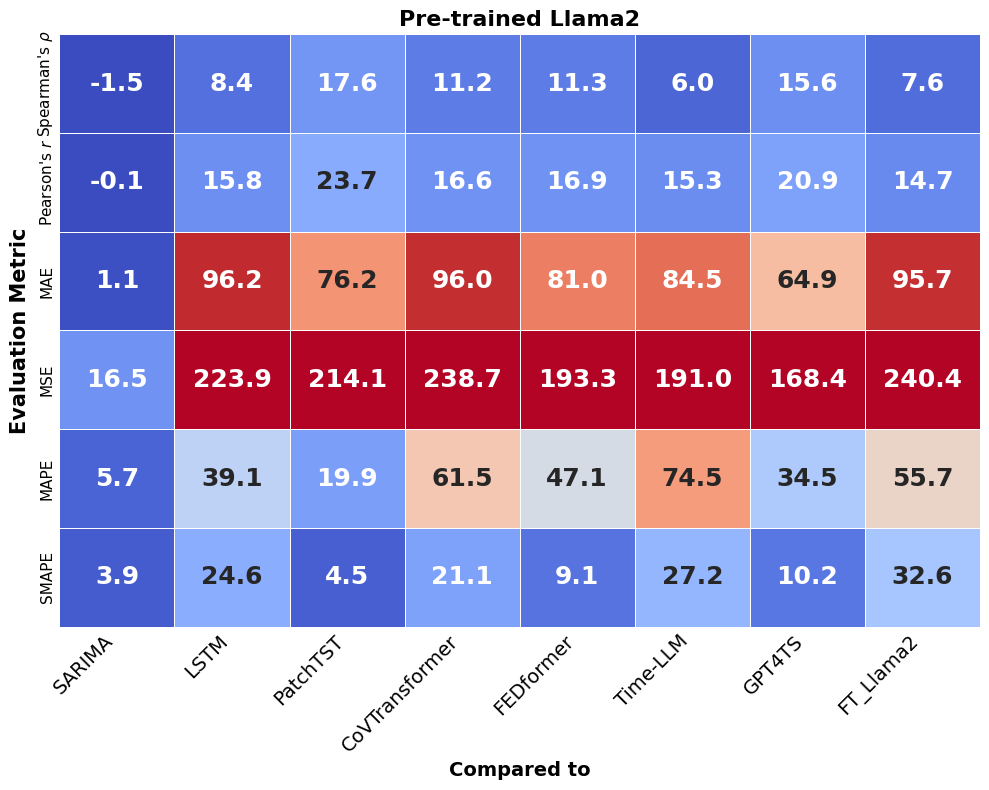

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === 构造数据 ===
data = {
    'SARIMA':    [-1.54, -0.10, 1.06, 16.50, 5.68, 3.87],
    'LSTM':      [8.36, 15.81, 96.25, 223.9, 39.08, 24.57],
    'PatchTST':  [17.62, 23.71, 76.18, 214.1, 19.94, 4.52],
    'CoVTransformer': [11.20, 16.59, 95.99, 238.7, 61.52, 21.08],
    'FEDformer': [11.28, 16.94, 80.97, 193.3, 47.12, 9.10],
    'Time-LLM':  [6.02, 15.29, 84.52, 191.0, 74.50, 27.20],
    'GPT4TS':    [15.64, 20.87, 64.92, 168.4, 34.49, 10.15],
    'FT_Llama2': [7.61, 14.71, 95.67, 240.4, 55.72, 32.58]
}

metrics = [
    r"Spearman's $\it{\rho}$",
    r"Pearson's $\it{r}$",
    "MAE",
    "MSE",
    "MAPE",
    "SMAPE"
]

df = pd.DataFrame(data, index=metrics)
df.index.name = "Evaluation Metric"

# === 设置色阶 ===
vmin = 0
vmax = 100

# === 绘图 ===
plt.figure(figsize=(10, 8))

ax = sns.heatmap(
    df,
    annot=True,
    fmt=".1f",
    cmap="coolwarm",
    vmin=vmin,
    vmax=vmax,
    cbar=False,                 # 去掉右侧 bar
    linewidths=0.5,
    linecolor="white",
    annot_kws={
        "size": 18,
        "weight": "bold"
    }
)

# === 美化坐标轴 ===
ax.tick_params(axis="both", length=0)

plt.title(
    "Pre-trained Llama2",
    fontsize=16,
    fontweight="bold"
)

ax.set_ylabel(
    "Evaluation Metric",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel(
    "Compared to",
    fontsize=14,
    fontweight="bold"
)

plt.xticks(
    rotation=45,
    fontsize=14,
    # fontweight="bold",
    ha="right"
)

plt.yticks(
    rotation=90,
    fontsize=11,
    # fontweight="bold"
)

plt.tight_layout()

plt.savefig(
    "/data_disk/lichx/Predict/Influenza_Forecasting/Output/r2/llama2_relative_improvement_heatmap_GA.svg",
    format="svg",
    bbox_inches="tight",
    transparent=True
)

plt.show()

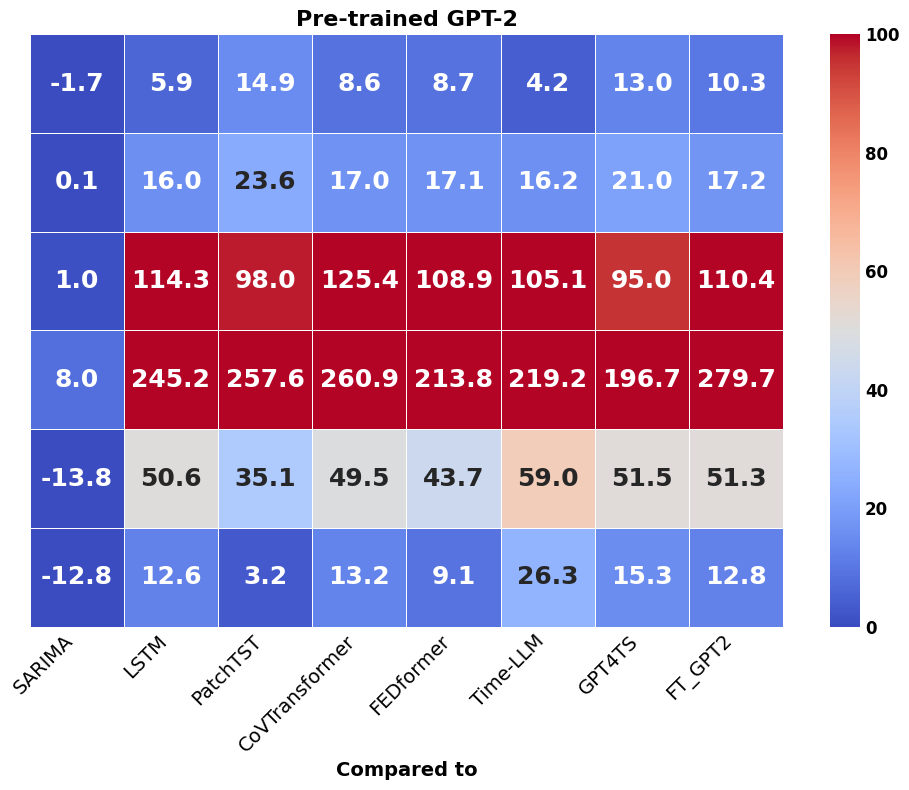

In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap

# === 构造数据 ===
data = {
    'SARIMA':    [-1.74, 0.11, 0.96, 8.00, -13.82, -12.77],
    'LSTM':      [5.87, 16.00, 114.27, 245.2, 50.59, 12.59],
    'PatchTST':  [14.91, 23.58, 98.02, 257.55, 35.09, 3.25],
    'CoVTransformer': [8.62, 16.99, 125.4, 260.9, 49.46, 13.25],
    'FEDformer': [8.718, 17.15, 108.9, 213.8, 43.69, 9.085],
    'Time-LLM':  [4.25, 16.24, 105.1, 219.2, 59.05, 26.26],
    'GPT4TS':    [13.03, 21.01, 94.97, 196.7, 51.46, 15.34],
    'FT_GPT2':   [10.27, 17.22, 110.37, 279.68, 51.28, 12.85]
}

metrics = [
    r"Spearman's $\it{\rho}$",
    r"Pearson's $\it{r}$",
    "MAE",
    "MSE",
    "MAPE",
    "SMAPE"
]

df = pd.DataFrame(data, index=metrics)

# === 色阶范围 ===
vmin = 0
vmax = 100

# === 绘图 ===
plt.figure(figsize=(10, 8))

ax = sns.heatmap(
    df,
    annot=True,
    fmt=".1f",
    cmap="coolwarm",
    vmin=vmin,
    vmax=vmax,
    cbar=True,
    cbar_kws={"label": ""},
    linewidths=0.5,
    linecolor="white",
    annot_kws={
        "size": 18,
        "weight": "bold"
    }
)

# === 美化坐标轴 ===
ax.tick_params(axis="both", length=0)

plt.title(
    "Pre-trained GPT-2",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel(
    "Compared to",
    fontsize=14,
    fontweight="bold"
)

# 去掉 y 轴名称
ax.set_ylabel("")

# 去掉 y 轴刻度标签
ax.set_yticks([])
ax.set_yticklabels([])

plt.xticks(
    rotation=45,
    fontsize=14,
    ha="right"
)

# 去掉 colorbar 的标签文字，只保留色条和刻度
cbar = ax.collections[0].colorbar
cbar.set_label("")
cbar.ax.tick_params(labelsize=12, length=0)

for label in cbar.ax.get_yticklabels():
    label.set_fontweight("bold")

plt.tight_layout()

plt.savefig(
    "/data_disk/lichx/Predict/Influenza_Forecasting/Output/r2/gpt2_heatmap_GA.svg",
    format="svg",
    bbox_inches="tight",
    pad_inches=0.08,
    transparent=True
)

plt.show()